# Session 5: Data Visualization with Matplotlib and Seaborn  
## Case Study: Understanding Bike Rental Patterns

In data science, once data has been collected and organized, the next step is to explore it in a way that reveals patterns and relationships. Tables and summary statistics are useful, but they do not always make trends or differences easy to see. In this notebook, we will learn how **data visualization** helps us better understand data by using the Bike Sharing dataset as a case study.

This notebook introduces **Matplotlib** and **Seaborn**, two important Python libraries for visualization. Through examples, we will learn how to create common plots such as line plots, histograms, boxplots, scatter plots, and heatmaps, and how to use them to communicate insights clearly. Since visualization is a key part of exploratory data analysis, this chapter will provide a practical foundation for later data analysis and modeling.

### Table of Contents
- **5.1 Loading and Understanding the Data**
    - 5.1.1 Importing Required Libraries
    - 5.1.2 Downloading the Dataset
    - 5.1.3 Inspecting the Structure
    - 5.1.4 Summary Statistics
    - 5.1.5 Key Variables for Our Analysis
    - 5.1.6 Connecting Back to the Business Question
    - 5.1.7 Creating Your First Plot
- **5.2 What Makes a Good Graph?**
    - 5.2.1 Start With a Clear Question
    - 5.2.2 A Weak Plot
    - 5.2.3 A Better Plot
    - 5.2.4 Design Principles to Remember
- **5.3 Matplotlib Fundamentals with One Variable Analysis**
    - 5.3.0 Plot Layout and Customization
    - 5.3.1 Line Plot: Rental Demand Over Time
    - 5.3.2 Histogram: Distribution of Daily Rentals
    - 5.3.3 Using a Boxplot to Detect Spread
- **5.4 Two Variables (Numeric vs Numeric): Does Temperature Affect Demand?**
    - 5.4.1 Scatter Plots
    - 5.4.2 Bubble Chart: Adding a Third Numerical Variable
- **5.5 Two Variables (Categorical vs Numeric): Do Working Days and Weather Matter?**
    - 5.5.1 Bar Plot: Average Rentals by Season
    - 5.5.2 Grouped (Side-by-side) Bar Charts
    - 5.5.3 Stacked Bar Charts
- **5.6. Subplots and Multi-Panel Figures**
    - 5.6.1 Comparing Distributions
    - 5.6.2 Comparing Multiple Relationships
    - 5.6.3 When Should You Use Subplots?
- **5.7 Introducing Seaborn: Simplifying Multi-Variable Visualizations**
    - 5.7.2 Grouped bar chart with hue
    - 5.7.3 Scatter Plot with Hue
    - 5.7.4 Boxplot with Hue
- **5.8. Correlation Analysis and Heatmaps**
    - 5.8.1 Understanding Correlation
    - 5.8.2 Computing the Correlation Matrix
    - 5.8.3 Visualizing Correlation with a Heatmap
    - 5.8.4 Important Limitationss
- **5.9. Regression and Trend Analysis**
    - 5.9.1 Adding a Regression Line
    - 5.9.2 Regression by Season (Interaction Insight)
    - 5.9.3 Connecting Correlation and Regression
    - 5.9.4 Important Cautions
- **5.10. Key Insights for the Bike Sharing Manager**
    - 5.10.1 Summary of Findings
    - 5.10.2 Final Reflection

# Chapter Introduction

Data visualization plays a crucial role in data analysis. Numerical tables alone often fail to reveal underlying patterns, while visual representations make relationships, trends, and structure easier to understand.

In this chapter, we will learn the fundamental methods of data visualization using **Matplotlib**, one of the most widely used plotting libraries in Python. We will also introduce **Seaborn**, a high-level library built on Matplotlib that simplifies statistical and comparative visualizations.

Rather than studying visualization techniques in isolation, we will apply them to a single, coherent business scenario using the **Bike Sharing dataset**:

> The city’s bike-sharing manager wants to understand what drives rental demand.

Using visualization as our primary analytical tool, we will explore time trends, group differences, and relationships between variables to generate actionable insights.

# Business Context

The city operates a bike-sharing program. Daily rental counts fluctuate depending on:

- Weather
- Temperature
- Season
- Working day vs weekend
- Other environmental factors

The manager has asked:

> "What factors most influence daily bike rentals, and how can we use this information to plan operations?"

Our task is to use visualization to explore patterns in the data before jumping to formal modeling.

This lecture focuses on:
- Building clean, interpretable plots
- Comparing groups
- Understanding distributions
- Exploring relationships between variables
- Identifying patterns visually

# 5.1 — Loading and Understanding the Data

Before we begin visualizing patterns, we need to:

1. Load the dataset
2. Understand its structure
3. Identify key variables
4. Clarify what we are trying to explain or predict  

Good visualization starts with understanding the data you are working with.

## 5.1.1 Importing Required Libraries

We will use:

- **NumPy** for numerical operations
- **Pandas** for handling tabular data
- **Matplotlib** for core plotting functionality
- **Seaborn** for higher-level statistical visualization

Matplotlib gives us full control.
Seaborn builds on top of Matplotlib and simplifies grouped and statistical plots.

In [2]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
%matplotlib inline

### Why Do We Import These Libraries?

In Matplotlib, most plotting functions are accessed through the `pyplot` module.  
By writing:

`import matplotlib.pyplot as plt`

we can use the short form `plt.function_name()` instead of the full name `matplotlib.pyplot.function_name()`. This keeps our code clean and readable.

`Seaborn` is built on top of Matplotlib and provides improved default styles and convenient functions for statistical visualization. It allows us to create cleaner and more informative graphics with less code.

The line:

`%matplotlib inline`

is a Jupyter Notebook command that ensures plots are displayed directly below the code cells. When working in Jupyter, this line is necessary to properly render figures.

Setting a visual style at the beginning ensures:

- Consistent formatting  
- Clear gridlines  
- Cleaner default colors  

This improves readability and interpretability without requiring additional customization later.

## 5.1.2 Downloading the Dataset

We will use the **UCI Bike Sharing Dataset**, which contains daily rental information
for a bike-sharing system.

The dataset includes:

- Weather conditions
- Temperature
- Humidity
- Working day indicators
- Total number of bike rentals per day

We will download the dataset directly from the UCI repository.

In [3]:
import requests
import zipfile
import io

# URL of the dataset
url = "https://cdn.uci-ics-mlr-prod.aws.uci.edu/275/bike%2Bsharing%2Bdataset.zip"

# Download the file
response = requests.get(url)

# Extract the zip file
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    z.extractall()

print("Dataset downloaded and extracted successfully.")

Dataset downloaded and extracted successfully.


The dataset contains two main files:

- `day.csv` → Daily aggregated data
- `hour.csv` → Hourly data

For this lecture, we will use **daily data** to keep the analysis simple and clear.

In [4]:
# Load daily dataset
df = pd.read_csv("day.csv")

# Display first 5 rows
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


## 5.1.3 Inspecting the Structure

Before visualizing anything, we should understand:

- How many observations do we have?
- What are the column names?
- What types of variables are included?
- What do the summary statistics look like?

Exploratory data analysis always begins with structural inspection.

In [5]:
# Shape of dataset
print("Dataset shape:", df.shape)

# Data types and missing values
df.info()

Dataset shape: (731, 16)
<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 91.5 KB


### What Do We Learn from This Output?

#### 1. Dataset Size

- The dataset contains **731 observations** and **16 variables**.  
- Each observation represents **one day of bike rentals**.

This means we have two full years of daily data.

---

#### 2. Missing Values

Each column shows **731 non-null values**, which means:

- There are **no missing values** in this dataset.
- We can proceed with analysis without additional data cleaning.

---

#### 3. Types of Variables

We observe three main data types:

- `int64` → Integer variables (e.g., season, workingday, cnt)  
- `float64` → Continuous numerical variables (e.g., temperature, humidity)  
- `object` → Text data (`dteday`, the date)

However, not all integer variables represent numerical quantities.

For example:

- `season`  
- `weathersit`  
- `workingday`  
- `holiday`  
- `weekday`  

These are **categories encoded as numbers**, not true numerical measurements.

Understanding this distinction is important because categorical variables are analyzed differently from continuous variables in visualization.

---

#### 4. Key Variable of Interest

For our business question, the most important variable is:

→ `cnt` (total daily rentals)

This variable measures overall daily demand and will be the primary quantity we analyze throughout the chapter.

---

## 5.1.4 Summary Statistics

Now let’s examine basic summary statistics for numerical variables.

In [6]:
# Basic summary statistics
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


### Interpreting the Summary Statistics

The summary table provides important information about the numerical variables.

Let’s focus on the most relevant one: **`cnt` (total rentals)**.

### Rental Demand (`cnt`)

- **Average daily rentals:** 4504 bikes  
- **Median rentals:** 4548 bikes  

The mean and median are very close, suggesting that the distribution may be relatively symmetric.

- **Minimum:** 22 rentals  
- **Maximum:** 8714 rentals  

This shows a very large range in demand. Some days have extremely low rentals, while others are very high.

- **Standard deviation:** 1937  

This indicates substantial variability in daily demand.

At this stage, summary statistics help us understand:

- Typical values
- Ranges
- Variability
- Potential relationships to investigate

However, tables alone are not sufficient.

To truly understand distributions and patterns,
we need visualizations.

---

## 5.1.5 Key Variables for Our Analysis

The most important variable for the manager is:

- **`cnt`** — Total number of rentals per day
"
This is our "target variable".

Other important explanatory variables include:

### Numerical Variables
- `temp` → Normalized temperature
- `hum` → Humidity
- `windspeed` → Wind speed

### Categorical Variables
- `season` → Season (1–4)
- `weathersit` → Weather situation
- `workingday` → 1 if working day, 0 if weekend/holiday

Understanding the type of each variable is essential,
because the type determines which visualization is appropriate.

For example:

- Numerical vs Numerical → Scatter plot
- Categorical vs Numerical → Bar chart
- Single Numerical variable → Histogram or Boxplot

In [7]:
print("Unique seasons:", df['season'].unique())
print("Unique weather situations:", df['weathersit'].unique())
print("Working day values:", df['workingday'].unique())

Unique seasons: [1 2 3 4]
Unique weather situations: [2 1 3]
Working day values: [0 1]


Notice that some categorical variables are encoded as numbers.

For example:

- `season` uses numbers 1–4
- `weathersit` uses numbers 1–4
- `workingday` uses 0 and 1

These are **categories**, not quantities.

This distinction is extremely important.

Even though they are stored as numbers,
we should treat them as categorical variables during visualization.

---

## 5.1.6 Connecting Back to the Business Question

Now that we understand the structure of the dataset, we can begin asking:

- What does rental demand look like?
- Does temperature influence demand?
- Do working days matter?
- Does weather impact rentals?

## 5.1.7 Creating Your First Plot

Before we discuss what makes a good graph, let’s create our first plot.

→ We can generate a plot just by using `plt.plot()`

This is our first step toward visual exploration. Let’s visualize total rentals over time.

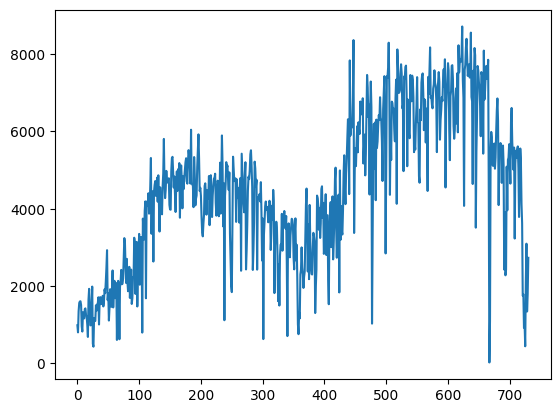

In [8]:
plt.plot(df["cnt"])
plt.show()

Take a moment to observe the graph.

*   The x-axis represents the index, which represents day number.
*   The y-axis represents total rentals on that day.

This plot works...but does it communicate clearly?

# 5.2 What Makes a Good Graph?

Before creating visualizations, we must understand an important principle: A graph is a communication tool.

A good graph should:

- Clearly answer a question
- Be easy to interpret
- Avoid unnecessary clutter
- Accurately represent the data
- Guide the viewer's attention to what matters

## 5.2.1 Start With a Clear Question

Every visualization should answer a specific question.

In our case:

- How does rental demand change over time?
- Does temperature influence rentals?
- Are weekends different from working days?
- Does bad weather reduce usage?

Without a guiding question, a graph becomes unfocused and confusing.

Let’s go back to the plot we created in section 5.1.7.

## 5.2.2 A Weak Plot

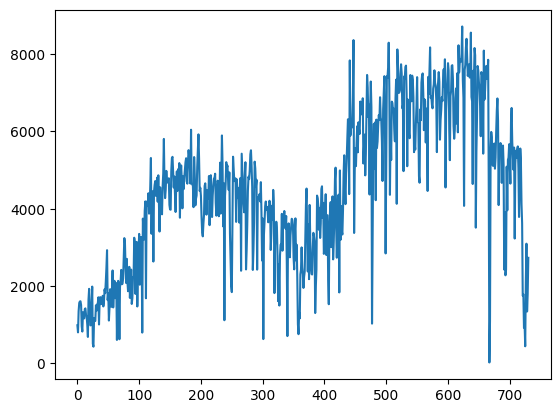

In [9]:
plt.plot(df["cnt"])
plt.show()

The graph has several problems:

- No title
- No axis labels
- The x-axis is unclear (what do the numbers represent?)
- No context is provided
- Readers won't know what "cnt" means

## 5.2.3 A Better Plot

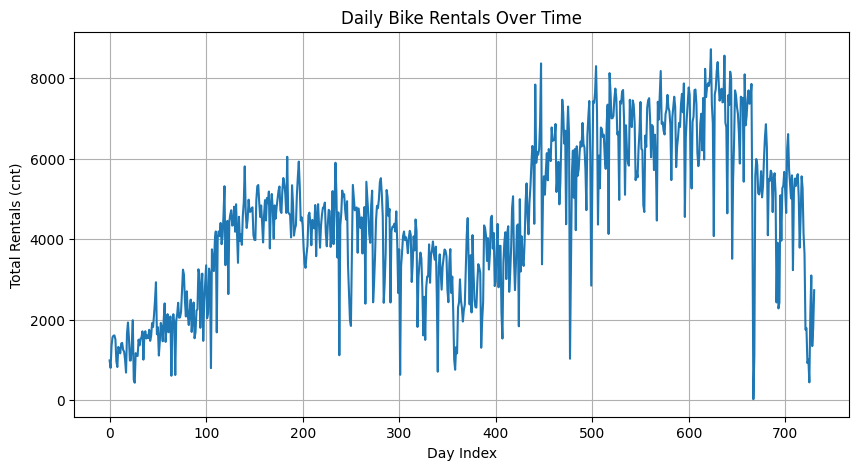

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(df["cnt"])

plt.title("Daily Bike Rentals Over Time")
plt.xlabel("Day Index")
plt.ylabel("Total Rentals (cnt)")
plt.grid(True)

plt.show()

Compare the two graphs. Do you notice the differences?

## 5.2.4 Design Principles to Remember

From this example, we learn that good graphs should include:

1. A clear and descriptive title  
2. Informative axis labels  
3. Appropriate scaling  
4. Minimal but helpful visual aids (like gridlines)  

As we build more complex visualizations, we will apply these principles consistently.

---

# 5.3 Matplotlib Fundamentals with One Variable Analysis

Matplotlib is the foundational plotting library in Python.

It gives us fine-grained control over:

- Plot types
- Labels
- Titles
- Colors
- Legends
- Figure size
- Layout

## 5.3.0 Plot Layout and Customization

Before we get familiar with different kinds of plots, we'll explore how to customize various elements of a graph using Matplotlib.

**Graph Title and Axis Labels**

*   `plt.title()`: Adds a title displayed at the top of the graph.
*   `plt.xlabel()`: Sets the label for the X-axis.
*   `plt.ylabel()`: Sets the label for the Y-axis.


These functions take the text you want to display as a string argument. Ex. `plt.title("Title")`

**Grid Lines**

*   `plt.grid(True)`: Displays grid lines in the background of the graph.

You can toggle grid lines on and off by passing True/False as an argument.

**Graph Size Adjustment**

*   `plt.figure(figsize=(width, height))`: Customizes the width and height of the graph.
Arguments specify width and height in order, typically in inches.

**Font Size Customization**

Many functions (title(), xlabel(), ylabel(), etc.) have a fontsize argument that allows you to adjust the text size.

When making the graph larger, proportionally increase the font size for better readability.
Refer to the official Matplotlib documentation for more detailed customization options.

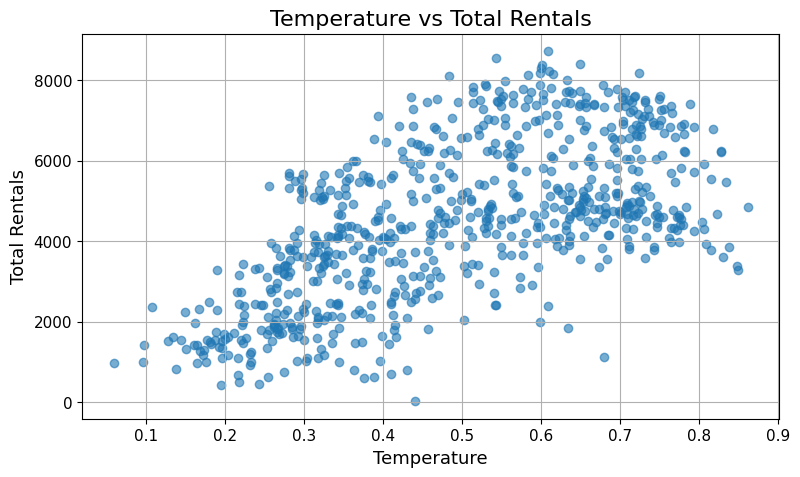

In [11]:
plt.figure(figsize=(9, 5))

plt.scatter(df["temp"], df["cnt"], alpha=0.6)

plt.title("Temperature vs Total Rentals", fontsize=16)
plt.xlabel("Temperature", fontsize=13)
plt.ylabel("Total Rentals", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.grid(True)

plt.show()

**Graph Partitioning**

Using `plt.subplot()`, you can divide a graph into multiple sections.

`plt.subplot(rows, columns, index)` divides a figure into a grid.

For example:

- `plt.subplot(2,1,1)` means:
  - 2 rows
  - 1 column
  - First position

This allows us to compare multiple visualizations within the same figure.

Using subplots is useful when:
- Comparing related variables
- Showing trends together
- Maintaining visual consistency

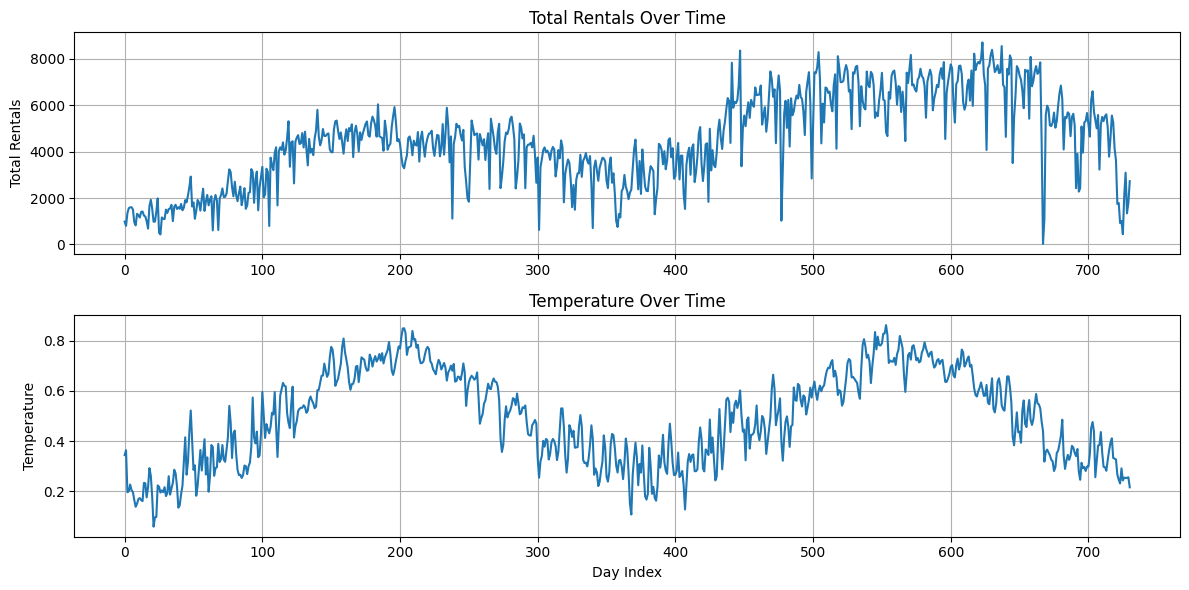

In [12]:
# Specify the size of the figure
plt.figure(figsize=(12, 6))

# First subplot (2 rows, 1 column, position 1)
plt.subplot(2, 1, 1)
plt.plot(df["cnt"])
plt.title("Total Rentals Over Time")
plt.ylabel("Total Rentals")
plt.grid(True)

# Second subplot (2 rows, 1 column, position 2)
plt.subplot(2, 1, 2)
plt.plot(df["temp"])
plt.title("Temperature Over Time")
plt.ylabel("Temperature")
plt.xlabel("Day Index")
plt.grid(True)

plt.tight_layout()
plt.show()

**Non-English Characters in Graphs**

By default, matplotlib does not support characters outside the English alphabet. When running code that includes labels in languages other than English, many warning messages appear, and the resulting graph shows garbled characters in place of the labels.

`【The following code will produce warning messages】`

C:\Users\ThinkPad\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12524 (\N{KATAKANA LETTER RE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ThinkPad\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ThinkPad\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ThinkPad\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12523 (\N{KATAKANA LETTER RU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ThinkPad\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning:

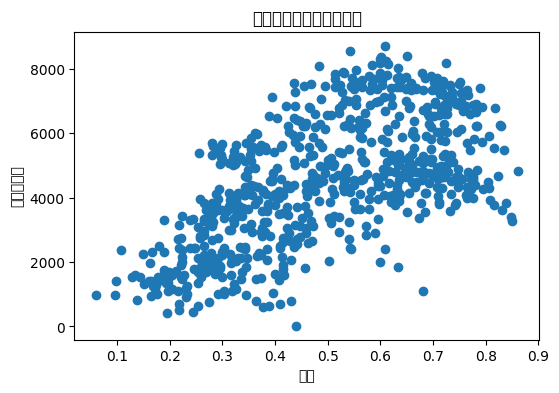

In [13]:
plt.figure(figsize=(6,4))
plt.scatter(df["temp"], df["cnt"])

plt.title("気温とレンタル数の関係")
plt.xlabel("気温")
plt.ylabel("レンタル数")

plt.show()

To avoid this, when drawing graphs in Matplotlib, it's best to use the alphabet for labels and graph titles to prevent garbled text.

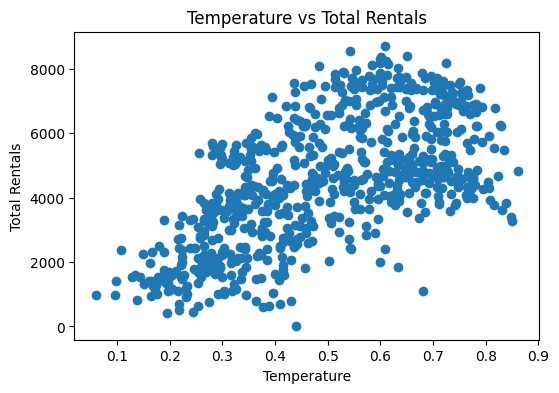

In [14]:
plt.figure(figsize=(6,4))
plt.scatter(df["temp"], df["cnt"])

plt.title("Temperature vs Total Rentals")
plt.xlabel("Temperature")
plt.ylabel("Total Rentals")

plt.show()

## 5.3.1 Line Plot: Rental Demand Over Time

A **line plot** is a graph that plots points by connecting them on an`x-y`coordinate system based on two sets of data. To plot a line plot in matplotlib, you can use `plt.plot()` as we have done previously.

A line plot is useful when we want to see how something changes step by step. Since our dataset records bike rentals on a daily basis, a line plot is an appropriate tool to examine how rental demand evolves over time.

By plotting the total daily rentals (cnt) against time, we aim to answer the following question:

* What patterns can be observed in bike rental demand  over the two-year period?
* Is there a visible trend, seasonality, or strong day-to-day fluctuation?

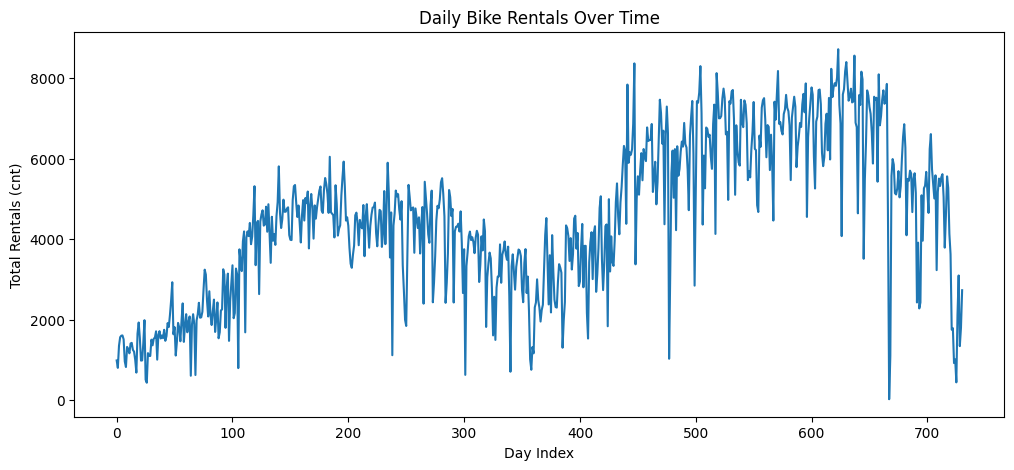

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(df["cnt"])

plt.title("Daily Bike Rentals Over Time")
plt.xlabel("Day Index")
plt.ylabel("Total Rentals (cnt)")

plt.show()

Time-series data should be plotted against a proper time axis. Since actual dates have more information than indeces, we should use the actual date variable `dteday`.

To improve clarity, we:

- Convert the `dteday` column to a datetime format  
- Display one tick per month  
- Format the labels as `YYYY-MM`  
- Rotate the labels slightly to prevent overlap  

This ensures the time axis is both meaningful and readable.

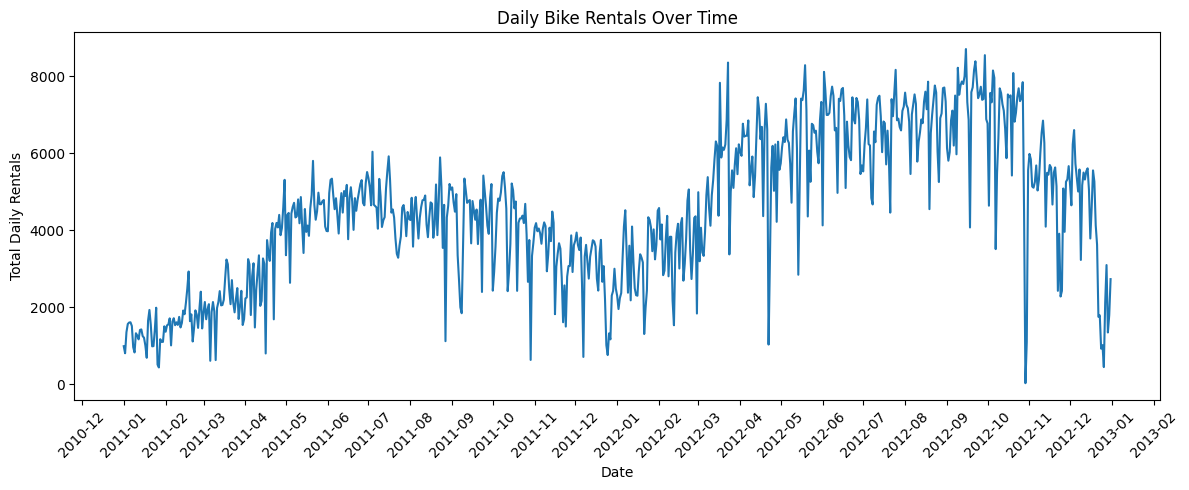

In [15]:
import matplotlib.dates as mdates

# Convert to datetime
df['dteday'] = pd.to_datetime(df['dteday'])

plt.figure(figsize=(12, 5))
plt.plot(df['dteday'], df['cnt'])

plt.title("Daily Bike Rentals Over Time")
plt.xlabel("Date")
plt.ylabel("Total Daily Rentals")

# Show one tick per month
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Interpreting the Line Plot

Several important patterns emerge from this visualization.

First, there is a noticeable upward shift in overall demand when comparing the first year to the second year. Rental counts are generally higher in the later portion of the dataset, suggesting increasing popularity of the bike-sharing system over time.

Second, a seasonal pattern is visible. Demand rises during the middle of each year and declines toward the beginning and end of each year. This repeating cycle indicates strong yearly seasonality, likely influenced by weather conditions and outdoor activity patterns.

Third, the plot shows substantial short-term fluctuations. Even during high-demand periods, there are sharp drops on specific days. These sudden decreases may reflect external factors such as poor weather conditions, holidays, or other temporary disruptions.

Overall, the line plot reveals that rental demand follows a structured pattern rather than random variation. It exhibits long-term growth, strong seasonality, and noticeable daily volatility.

### Plotting Multiple Lines

So far, we have examined total rental demand. However, to obtain a deeper insight of the demand trend, we need a finer analysis for the data. We here note that total demand consists of two distinct user groups: casual users and registered users. Understanding their behavior separately will allow us to identify differences in usage patterns and customer structure.

This leads to the following question:

* How do rental patterns differ between casual and registered users over time?
* Are both groups growing similarly, and do they respond differently to seasonal changes?

To compare the trends, we plot both time series in the same figure:

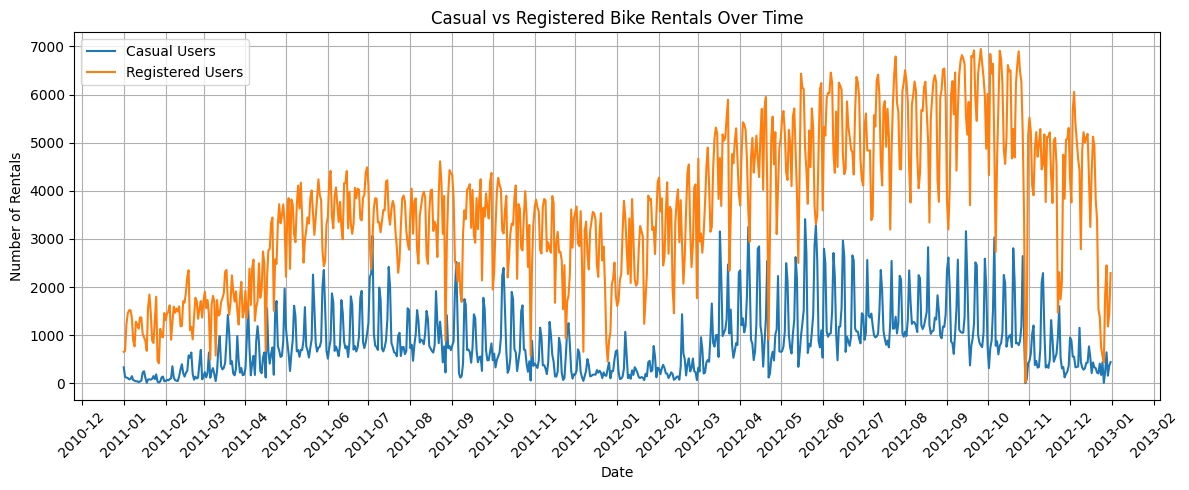

In [17]:
plt.figure(figsize=(12, 5))

plt.plot(df["dteday"], df["casual"], label="Casual Users")
plt.plot(df["dteday"], df["registered"], label="Registered Users")

plt.title("Casual vs Registered Bike Rentals Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Rentals")

# Monthly ticks
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.xticks(rotation=45)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Interpreting the Line Plots

Several differences emerge from the visualization.

First, registered users consistently account for the majority of rentals throughout the entire period. Their rental counts are substantially higher than those of casual users, indicating that the system relies primarily on recurring customers.

Second, both user groups display seasonal patterns. This repeating cycle appears in both groups, suggesting that overall demand for bike rentals is strongly influenced by season.

Third, the upward shift from the first year to the second year is visible for both groups, but it is especially noticeable for registered users. This suggests that growth in total demand is largely driven by an increase in regular customers rather than occasional users.

Overall, the comparison reveals structural differences between user types. Registered users form a stable and growing base of demand, while casual users contribute more seasonal and volatile usage. This distinction is important for demand forecasting, pricing strategies, and marketing decisions.

### <Practice Question 5.3.1.1 — Monthly Rental Trend>

Daily data can be noisy and difficult to interpret visually. Instead of plotting daily rentals, create a line plot showing
**average monthly rental demand**.

Steps:

1. Convert the date to a year–month period.
2. Group the data by year–month.
3. Compute the average total rentals for each month.
4. Plot the monthly averages as a line plot.

After plotting, answer:

- Which months have the highest demand?
- Is the seasonal pattern clearer than in the daily plot?
- Why might monthly aggregation be useful for managers?

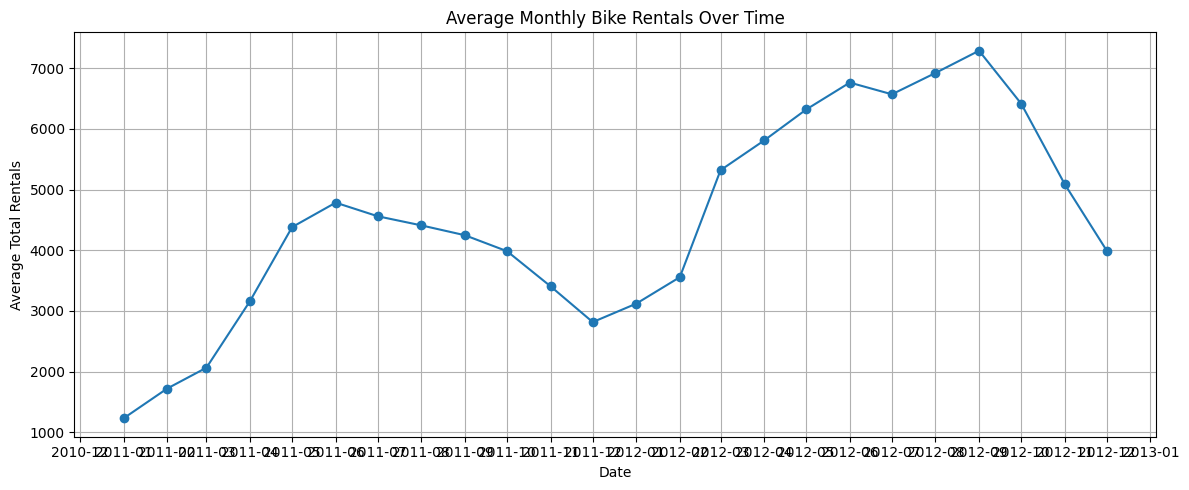

In [31]:
# Solution

import matplotlib.dates as mdates

# Ensure datetime format
df["dteday"] = pd.to_datetime(df["dteday"])

# Create year-month variable
df["year_month"] = df["dteday"].dt.to_period("M")

# Group by year-month and compute average rentals
monthly_avg = df.groupby("year_month")["cnt"].mean()

# Convert PeriodIndex back to timestamp for plotting
monthly_avg.index = monthly_avg.index.to_timestamp()

# Plot
plt.figure(figsize=(12, 5))

# WRITE ME
plt.plot(monthly_avg.index, monthly_avg.values , marker="o")
plt.title("Average Monthly Bike Rentals Over Time")
plt.xlabel("Date")
plt.ylabel("Average Total Rentals")
plt.grid(True)
# Monthly ticks
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

plt.tight_layout()
plt.show()

### <Practice Question 5.3.1.2 — Rolling Average Trend>

Daily rentals fluctuate substantially.

Create a line plot showing:

- The original daily rental counts
- A 7-day moving average of rentals

Plot both on the same figure.

After plotting, answer:

- Does the moving average make the trend clearer?
- What information is lost when smoothing the data?
- When would a manager prefer the smoothed version?

In [ ]:
# Solution

# Calculate 7-day moving average
df["rolling_7"] = # WRITE ME

plt.figure(figsize=(10, 5))

# WRITE ME

# Monthly ticks
plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

# WRITE ME

plt.tight_layout()
plt.show()

## 5.3.2 Histogram: Distribution of Daily Rentals

We next learn **histogram**, which display **frequency** (the nubmer of occurrences) or **distribution** of values in a dataset. Histograms are commonly used when observing the overall distribution of data. Unlike a line plot, which focuses on trends over time, a histogram helps us understand the overall shape and spread of the data.

Here, we analyze the distribution of total daily rentals (cnt) to answer the following question:

* How are daily rental counts distributed?
* Are most days concentrated within a certain range, and how common are extremely low or high rental days?

By using `plt.hist()` as shown below, you can create a histogram. The frequently-used arguments are `bins` and `range`. You can set `bins` to specify the number of bins or their edges. You can set `range` to specify the lower and upper range of the bins.

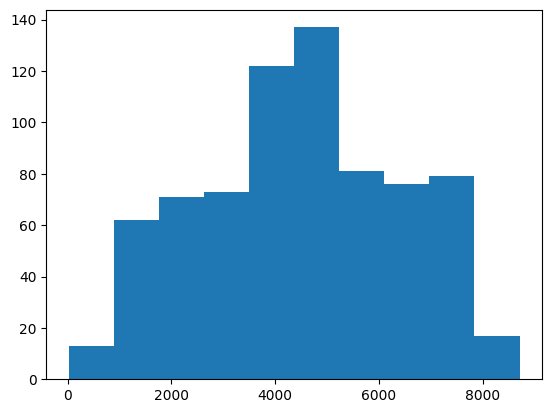

In [19]:
# Basic histogram
plt.hist(df['cnt'])
plt.show()

**Customizing the Histogram Step by Step**

The default histogram provides limited control over presentation.

1. **Add number of bins** → controls granularity
2. **Add color and edge lines** → improves readability
3. **Add title and axis labels** → communicate what the plot shows



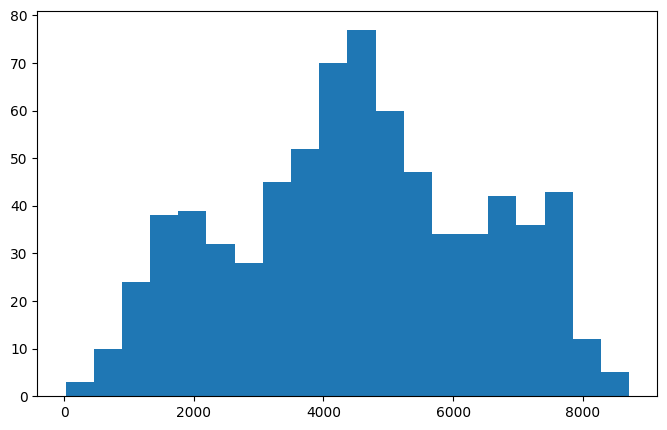

In [20]:
# Step 1: Increase bins
plt.figure(figsize=(8, 5))
plt.hist(df['cnt'], bins=20)  # 20 bins
plt.show()

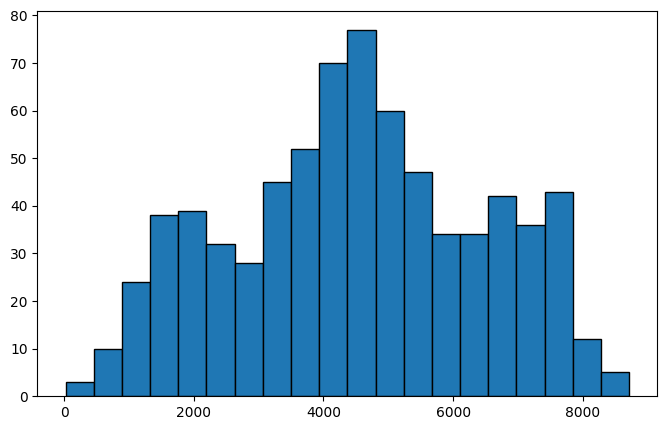

In [ ]:
# Step 2: Add edge
plt.figure(figsize=(8, 5))
plt.hist(df['cnt'], bins=20, edgecolor='black')
plt.show()

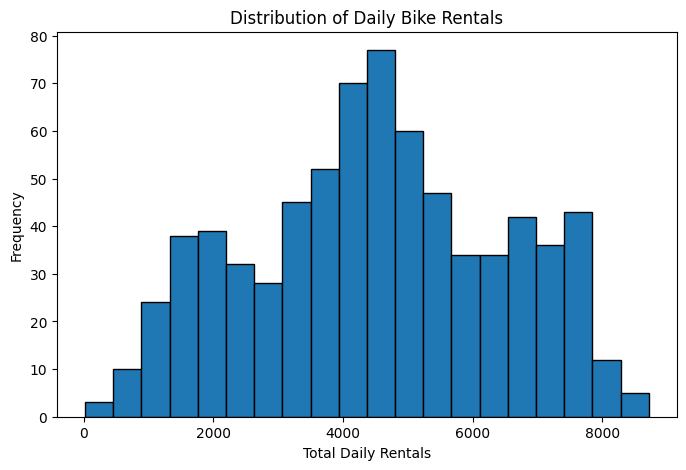

In [21]:
# Step 3: Add labels and title
plt.figure(figsize=(8, 5))
plt.hist(df['cnt'], bins=20, edgecolor='black')
plt.title("Distribution of Daily Bike Rentals")
plt.xlabel("Total Daily Rentals")
plt.ylabel("Frequency")
plt.show()

### Interpreting the Histogram

The histogram shows that most daily rental counts are concentrated roughly between 3,000 and 6,000 rentals per day. This indicates that the system operates within a fairly stable demand range during typical days.

Very low rental days (below 1,000) appear relatively infrequently, suggesting that extreme drops in demand are rare events. Similarly, extremely high rental days (above 8,000) occur but are less common than mid-range values.

The overall distribution appears relatively concentrated around the middle ranges, without obvious extreme clustering at either end. While the data show variability, the histogram alone does not provide strong evidence of pronounced skewness.

Overall, the histogram indicates that daily rentals cluster around a central range. Understanding this distribution is important before applying statistical models, as it helps determine whether assumptions such as normality are reasonable and whether transformation or scaling might be necessary.

`plt.hist()` function also includes various other arguments. You can check the available parameteres by using the "`?`" as shown below.

In [28]:
?plt.hist

Signature:
plt.hist(
    x: 'ArrayLike | Sequence[ArrayLike]',
    bins: 'int | Sequence[float] | str | None' = None,
    *,
    range: 'tuple[float, float] | None' = None,
    density: 'bool' = False,
    weights: 'ArrayLike | None' = None,
    cumulative: 'bool | float' = False,
    bottom: 'ArrayLike | float | None' = None,
    histtype: "Literal['bar', 'barstacked', 'step', 'stepfilled']" = 'bar',
    align: "Literal['left', 'mid', 'right']" = 'mid',
    orientation: "Literal['vertical', 'horizontal']" = 'vertical',
    rwidth: 'float | None' = None,
    log: 'bool' = False,
    color: 'ColorType | Sequence[ColorType] | None' = None,
    label: 'str | Sequence[str] | None' = None,
    stacked: 'bool' = False,
    data=None,
    **kwargs,
) -> 'tuple[np.ndarray | list[np.ndarray], np.ndarray, BarContainer | Polygon | list[BarContainer | Polygon]]'
Docstring:
Compute and plot a histogram.

This method uses `numpy.histogram` to bin the data in *x* and count the
number of values in eac

Additionally, you can use `help` to check the functionality of a function or a method. While `?` is a feature specific to the Jupyter environment (more precisely, IPython), `help` is a standard Python feature.

In [25]:
help(plt.hist)

Help on function hist in module matplotlib.pyplot:

hist(
    x: ArrayLike | Sequence[ArrayLike],
    bins: int | Sequence[float] | str | None = None,
    *,
    range: tuple[float, float] | None = None,
    density: bool = False,
    weights: ArrayLike | None = None,
    cumulative: bool | float = False,
    bottom: ArrayLike | float | None = None,
    histtype: Literal['bar', 'barstacked', 'step', 'stepfilled'] = 'bar',
    align: Literal['left', 'mid', 'right'] = 'mid',
    orientation: Literal['vertical', 'horizontal'] = 'vertical',
    rwidth: float | None = None,
    log: bool = False,
    color: ColorType | Sequence[ColorType] | None = None,
    label: str | Sequence[str] | None = None,
    stacked: bool = False,
    data=None,
    **kwargs
) -> tuple[np.ndarray | list[np.ndarray], np.ndarray, BarContainer | Polygon | list[BarContainer | Polygon]]
    Compute and plot a histogram.

    This method uses `numpy.histogram` to bin the data in *x* and count the
    number of values i

By default, Matplotlib determines bin edges automatically.
This may produce intervals that are difficult to interpret.

We can adjust bins by:

1. Specifying **number of bins** (`bins=20`) → Matplotlib chooses evenly spaced edges automatically  
2. Specifying **exact bin edges** (`bins=[0, 1000, 2000, 3000,...]`) → gives full control  

Explicit bin edges improve interpretability and allow consistent comparison across analyses.

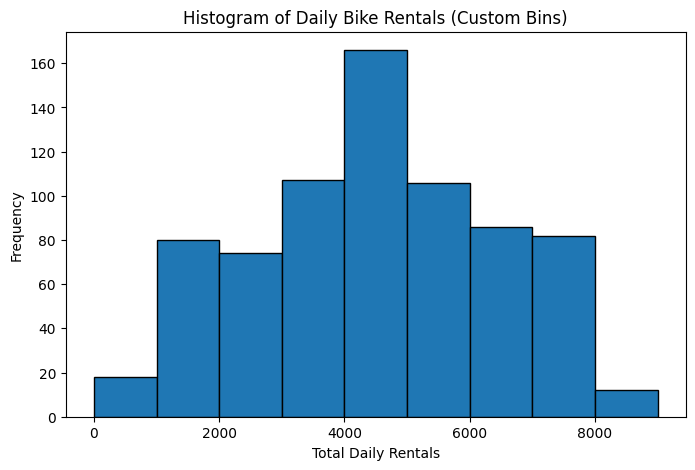

In [23]:
# Define bins manually
bin_edges = [0, 1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000]
plt.figure(figsize=(8, 5))
plt.hist(df['cnt'], bins=bin_edges, edgecolor='black')
plt.title("Histogram of Daily Bike Rentals (Custom Bins)")
plt.xlabel("Total Daily Rentals")
plt.ylabel("Frequency")
plt.show()

Bin edges can also be generated programmatically using:

`np.arange(start, stop, step)`.


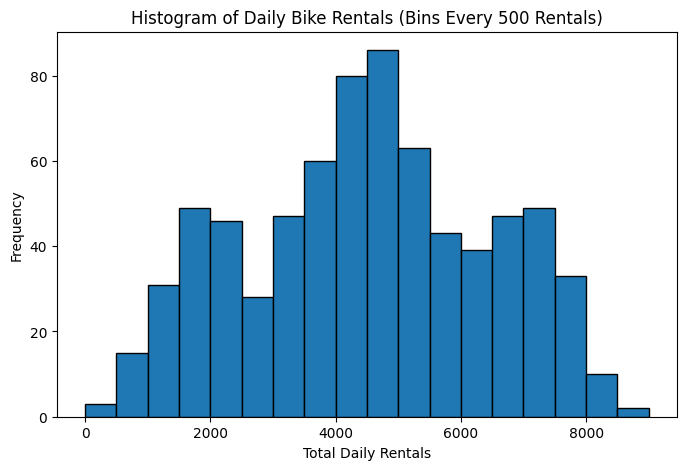

In [27]:
# Define bins efficiently
bin_edges = np.arange(0, 9500, 500)
# Note: The stop value is 9500 so that 9000 is included
plt.figure(figsize=(8, 5))
plt.hist(df['cnt'], bins=bin_edges, edgecolor='black')
plt.title("Histogram of Daily Bike Rentals (Bins Every 500 Rentals)")
plt.xlabel("Total Daily Rentals")
plt.ylabel("Frequency")
plt.show()

### <Practice Question 5.3.2.1>

Using the bike dataset:

1. Plot a histogram of daily rental counts (`df["cnt"]`) using:
   - 10 bins
   - 30 bins

2. Compare the two graphs:
   - How does changing the number of bins affect the appearance?
   - Which version better represents the distribution?

3. Based on the histogram:
   - Is the distribution symmetric or skewed?
   - Do extreme rental days appear common or rare?

In [ ]:
#Solution
plt.figure(figsize=(10, 4))

# 10 bins
# WRITE ME

# 30 bins
# WRITE ME

plt.tight_layout()
plt.show()

### <Practice Question 5.3.2.2>

Plot separate histograms for:

- Temperature (`df["temp"]`)
- Total rentals (`df["cnt"]`)

Display them using `plt.subplot()` in a 1×2 layout.

Then answer:

1. Which variable appears more symmetric?
2. Which variable shows more variability?
3. Which variable appears closer to a normal distribution?

In [ ]:
#Solution
plt.figure(figsize=(10, 4))

# Temperature distribution
# WRITE ME

# Rental distribution
# WRITE ME

plt.tight_layout()
plt.show()

### <Practice Question 5.3.2.3 — Weekday vs. Weekend Comparison>

Create separate histograms of total rentals (`df["cnt"]`) for:

- Weekdays only
- Weekends only

(Hint: Use the `workingday` column.)

Display them side by side using `plt.subplot()`.

Then analyze:

1. Which group has higher rental concentration?
2. Do weekends show more extreme high-rental days?
3. Is the distribution shape similar or different?

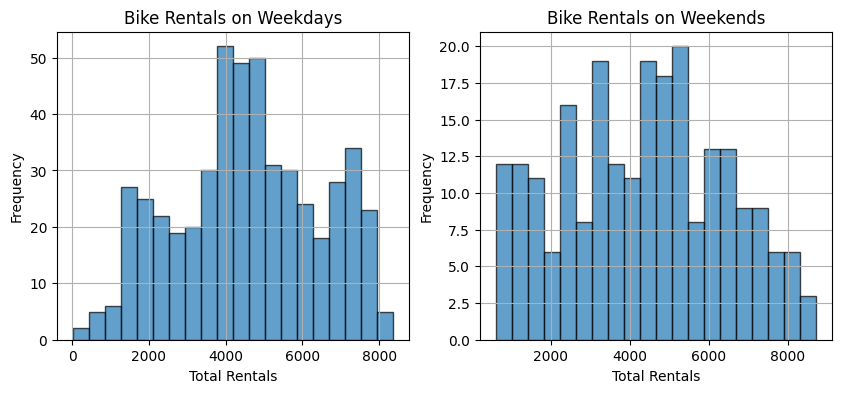

In [34]:
# Solution
weekday_rentals = df[df["workingday"] == 1]["cnt"]
weekend_rentals = df[df["workingday"] == 0]["cnt"]

plt.figure(figsize=(10, 4))

# Weekdays
plt.subplot(1, 2, 1)
plt.hist(weekday_rentals, bins=20, alpha=0.7, label="Weekdays", edgecolor='black')
plt.title("Bike Rentals on Weekdays")
plt.xlabel("Total Rentals")
plt.ylabel("Frequency")
plt.grid(True)      

plt.subplot(1, 2, 2)
plt.hist(weekend_rentals, bins=20, alpha=0.7, label="Weekends", edgecolor='black')
plt.title("Bike Rentals on Weekends")
plt.xlabel("Total Rentals")
plt.ylabel("Frequency")
plt.grid(True)      

## 5.3.3 Using a Boxplot to Detect Spread

A **boxplot** (box-and-whisker plot) provides a compact statistical summary of a numerical variable.

It visualizes:

- **Median** (center line inside the box)
- **Interquartile Range (IQR)** — the middle 50% of observations (Q1 to Q3)
- **Whiskers** — spread of typical values
- **Outliers** — unusually high or low observations

Unlike a histogram which shows distribution shape, a boxplot highlights key summary statistics concisely.

Boxplots are especially useful for:
- Detecting skewness
- Identifying extreme values
- Comparing distributions across groups

We use the boxplot to answer the following question:
* How dispersed are daily rentals, and are there extreme values?

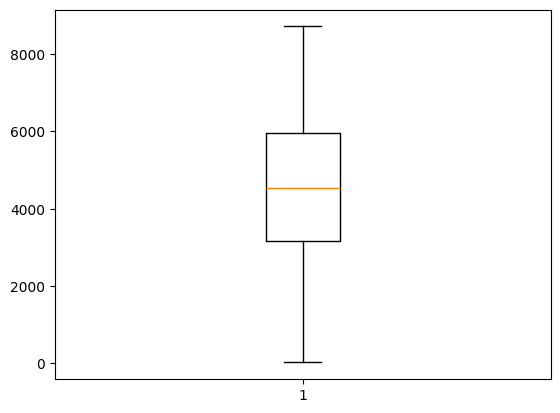

In [ ]:
# Step 1: Basic boxplot
plt.boxplot(df['cnt'])
plt.show()

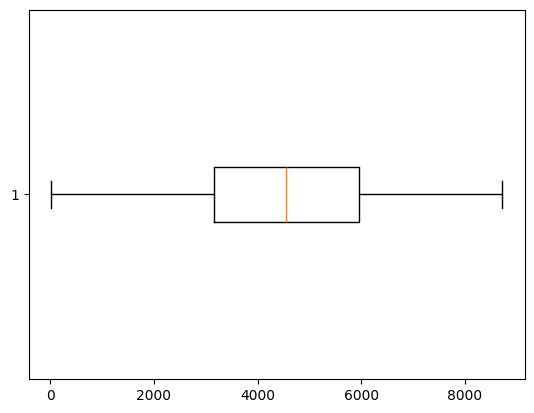

In [ ]:
# Step 2: horizontal boxplot for readability
plt.boxplot(df['cnt'], vert=False)
plt.show()

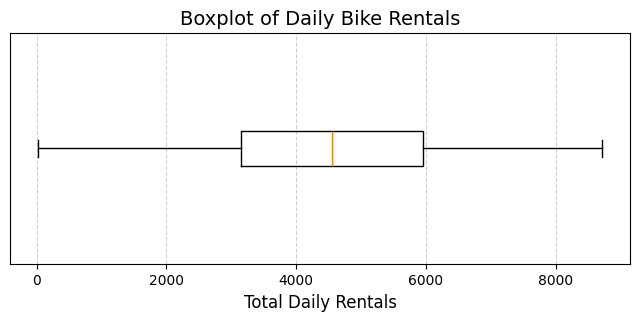

In [ ]:
# Step 3: add labels and title

plt.figure(figsize=(8, 3))

plt.boxplot(df["cnt"],
            vert=False)

plt.title("Boxplot of Daily Bike Rentals", fontsize=14)
plt.xlabel("Total Daily Rentals", fontsize=12)

plt.yticks([])  # remove unnecessary categorical axis
plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.show()

### Interpreting the Boxplot

The median daily rental count is located roughly around the mid-4,000 range, indicating that a typical day sees approximately 4,500 rentals.

The interquartile range (the width of the box) appears to span roughly from around 3,000 to 6,000 rentals. This means that 50% of all observed days fall within this range, confirming moderate variability in daily demand.

The whiskers extend to very low and very high values, indicating that rental counts can vary substantially across days. However, there are no isolated outlier markers shown in this plot, suggesting that extreme values are not separated from the overall distribution.

Overall, the boxplot confirms that daily demand is centered around a stable median but exhibits meaningful dispersion. This variability implies that operational decisions — such as staffing levels and bike allocation — should remain flexible to accommodate fluctuations in demand.

### <Practice Question 5.3.3.1>

Create a boxplot of temperature (`df["temp"]`).

1. Is temperature distribution symmetric?
2. Are there noticeable outliers?
3. Compare it visually to the rental boxplot.

In [ ]:
# Solution
plt.figure(figsize=(8, 3))

# WRITE ME

plt.show()

### <Practice Question 5.3.3.2>

Create separate boxplots for:

- Weekday rentals (`workingday == 1`)
- Weekend rentals (`workingday == 0`)

Display them vertically for comparison.

1. Which group has a higher median?
2. Which group shows greater variability?
3. Are outliers more common in one group?

In [ ]:
# Solution
weekday = # WRITE ME
weekend = # WRITE ME

plt.figure(figsize=(6, 5))

# WRITE ME

plt.show()

# 5.4 Two Variables (Numeric vs Numeric): Does Temperature Affect Demand?

We now investigate whether temperature influences daily bike rentals.

We are moving beyond single-variable analysis to see **relationships between two numeric variables**.

## 5.4.1 Scatter Plots

A **scatter plot** is a graph that plots points on an`x-y`coordinate system based on two sets of data. It can be created using `plt.scatter()`.

Scatter plots are useful for identifying:
* Direction of relationship (positive or negative)
* Strength of association
* Patterns such as linearity or curvature
* Outliers

Here, we explore whether temperature affects rental demand.

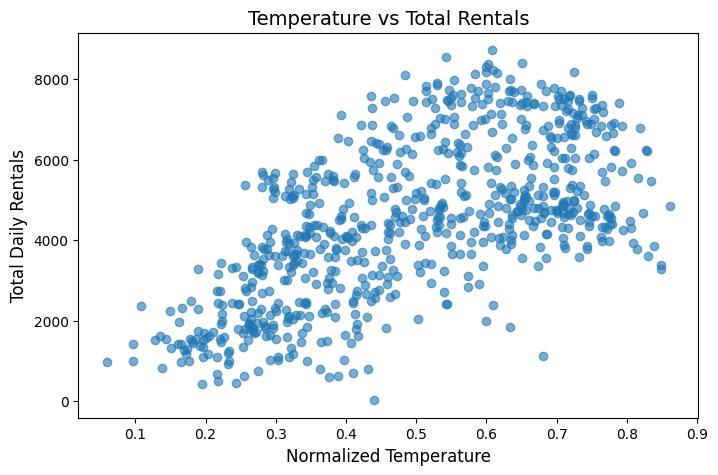

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(df["temp"], df["cnt"], alpha=0.6)

plt.title("Temperature vs Total Rentals", fontsize=14)
plt.xlabel("Normalized Temperature", fontsize=12)
plt.ylabel("Total Daily Rentals", fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.show()

### Interpreting the Plot

The scatter plot shows a positive relationship between temperature and total daily rentals. As temperature increases, rental demand generally rises. At lower temperatures, daily rentals remain relatively low. As temperature reaches moderate levels, rentals increase substantially, and the highest rental counts occur during warmer conditions.

However, the relationship does not appear perfectly linear. While rentals increase with temperature overall, the spread of data points becomes wider at moderate to high temperatures. This indicates that rental demand becomes more variable during favorable weather conditions.

Temperature appears to be an important factor influencing bike rental demand, but other variables likely contribute to fluctuations in daily usage.

### <Practice Question 5.4.1.1 — Humidity and Rental Demand>

Create a scatter plot showing the relationship between:

- Humidity (`hum`)
- Total rentals (`cnt`)

Add:
- A clear title
- Axis labels
- Transparency (`alpha`) to improve readability

After plotting, answer:

- Does humidity appear positively or negatively related to rentals?
- Is the relationship strong or weak?
- Do you observe any unusual clusters or patterns?

In [ ]:
# Solution

plt.figure(figsize=(8, 5))

# WRITE ME

plt.show()

### <Practice Question 5.4.1.2 — Temperature and Casual Users>

Create a scatter plot using:

- Temperature (`temp`) on the x-axis
- Casual rentals (`casual`) on the y-axis

Answer:

- Does temperature affect casual users differently than total demand?
- Would you describe the relationship as strong, moderate, or weak?

In [ ]:
# Solution

plt.figure(figsize=(8, 5))

# WRITE ME

plt.show()

### 5.4.2 Bubble Chart: Adding a Third Numerical Variable

A **bubble chart** is an extension of a scatter plot. While a scatter plot shows the relationship between two numerical variables,
a bubble chart adds a third variable using the **size of each point**.

In this example, we examine:

- X-axis → Temperature (`temp`)
- Y-axis → Total rentals (`cnt`)
- Bubble size → Wind speed (`windspeed`)

This allows us to explore whether wind speed influences the relationship
between temperature and rentals. Each point represents one day in the dataset. Larger bubbles correspond to higher wind speeds, allowing us to visually assess whether windy conditions are associated with changes in rental demand.

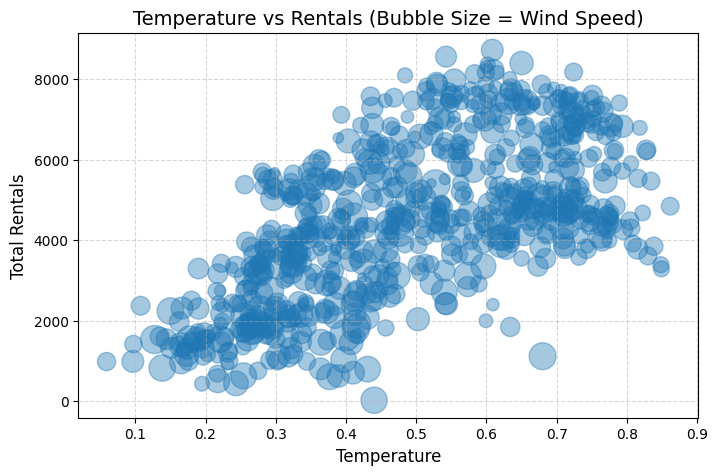

In [ ]:
plt.figure(figsize=(8, 5))

# Scale windspeed so bubbles have an appropriate size
bubble_size = df["windspeed"] * 1000

plt.scatter(df["temp"],
            df["cnt"],
            s=bubble_size,
            alpha=0.4)

plt.title("Temperature vs Rentals (Bubble Size = Wind Speed)", fontsize=14)
plt.xlabel("Temperature", fontsize=12)
plt.ylabel("Total Rentals", fontsize=12)

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

### Interpreting the Plot

The bubble chart retains the overall positive relationship observed earlier between temperature and rental demand. As temperature increases, the number of daily rentals generally rises.

By incorporating bubble size, we can also examine whether wind speed appears to influence this relationship. Larger bubbles represent days with higher wind speeds. If high wind speeds significantly reduced bike usage, we would expect larger bubbles to appear more frequently at lower rental values.

In this visualization, however, bubble sizes appear scattered across the plot without a visible pattern. Days with higher wind speeds occur across a range of rental levels, suggesting that wind speed may not be a dominant factor influencing demand compared with temperature.

### <Practice Question 5.4.2.1>

Create a bubble chart where:

- X-axis → Temperature (`temp`)
- Y-axis → Total rentals (`cnt`)
- Bubble size → Humidity (`hum`)

1. Does high humidity appear to reduce rentals?
2. Is the relationship between temperature and rentals still visible?

In [ ]:
# Solution
plt.figure(figsize=(8, 5))

bubble_size = # WRITE ME

plt.scatter(df["temp"],
            df["cnt"],
            s= # WRITE ME,
            alpha=0.4)

# WRITE ME

plt.show()

### Important Note

Bubble charts can become visually cluttered when the dataset is large.
In such cases, consider:

- Reducing bubble size
- Increasing transparency
- Sampling the data
- Using alternative visualizations

# 5.5 Two Variables (Categorical vs Numeric): Do Working Days and Weather Matter?

In the previous section, we examined relationships between **two numerical variables**, such as temperature and total rentals. We now shift to a different type of comparison: categorical vs numerical variables. Instead of analyzing individual data points, we group observations into categories and compare their average rental demand.

Typical questions include:

* Are rentals higher on working days or weekends?

* Do weather conditions affect bike usage?

* Are there differences in demand across seasons?

To analyze these types of questions, we often compute group averages and visualize them using bar charts.

## 5.5.1 Bar Plot: Average Rentals by Season

A **bar chart** is commonly used to compare values across categories. Each bar represents a category, and the bar height corresponds to the value being compared (in this case, **average rentals**). In this example, we calculate the **average number of rentals for each season** and display the results in a bar chart.

To display a bar chart, you can use the `plt.bar()` function. If you wish to display labels on the bars, you can specify them using the `xticks` function as shown below. Additionally, when executed without adjustments, the graph will be left-aligned. To center the graph, it is advisable to use the `align = 'center'` argument.



### Vertical Bar Chart: Average Rentals by Season

In the dataset, the `season` variable is encoded numerically:

| Code | Season |
|-----|------|
| 1 | Winter |
| 2 | Spring |
| 3 | Summer |
| 4 | Autumn |

To improve readability, we convert these numeric codes into their corresponding season names before plotting.

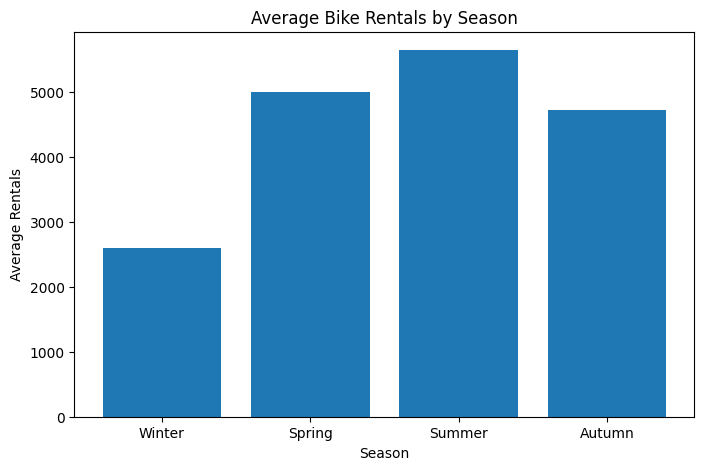

In [ ]:
# Convert season codes to readable labels
season_map = {1: "Winter", 2: "Spring", 3: "Summer", 4: "Autumn"}

season_avg = (
    df.assign(Season=df["season"].map(season_map))
      .groupby("Season")["cnt"]
      .mean()
      .reindex(season_map.values())
)

plt.figure(figsize=(8,5))
plt.bar(season_avg.index, season_avg.values)

plt.title("Average Bike Rentals by Season")
plt.xlabel("Season")
plt.ylabel("Average Rentals")

plt.show()

From the visualization, we can observe a seasonal pattern: rental demand is lowest during winter and rises substantially as the weather becomes warmer. The highest demand occurs during summer, while autumn remains relatively strong but slightly lower than the summer peak. This suggests that seasonal weather conditions play an important role in determining bike rental demand.

### Horizontal Bar Chart

You can create a horizontal bar chart using `plt.barh()`. Horizontal bar charts are sometimes easier to read when category labels are long or when comparing many groups. Note that in a horizontal chart the **axes are reversed**: the categories appear on the y-axis, and the values extend along the x-axis.

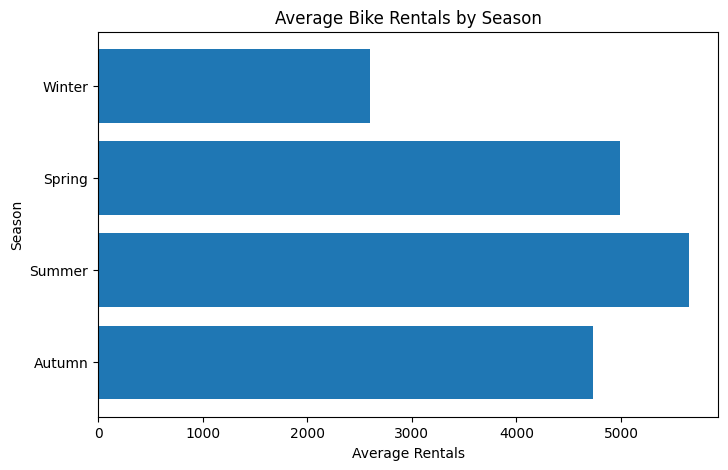

In [ ]:
plt.figure(figsize=(8,5))

plt.barh(season_avg.index[::-1], season_avg.values[::-1])

plt.title("Average Bike Rentals by Season")
plt.ylabel("Season")
plt.xlabel("Average Rentals")

plt.show()

### <Practice Question 5.5.1.1>

Create a bar chart showing the **average temperature by season**.

1. Which season has the highest average temperature?
2. Does the temperature pattern align with rental patterns?

In [ ]:
# Solution

season_map = {1: "Winter", 2: "Spring", 3: "Summer", 4: "Autumn"}

temp_avg = (
    df.assign(
        Season=pd.Categorical(
            df["season"].map(season_map),
            categories=season_map.values(),
            ordered=True
        )
    )
    # WRITE ME (hint: groupby + mean)
)

# WRITE ME

print("Season with highest average temperature:", temp_avg.idxmax())

### <Practice Question 5.5.1.2>

Create a bar chart showing the **total rentals by month**.

1. Which month has the highest total rentals?
2. Is the pattern consistent with seasonal trends observed earlier?

In [ ]:
# Solution
monthly_total = # WRITE ME

plt.figure(figsize=(10, 5))

# WRITE ME

plt.show()

print("Month with highest total rentals:", monthly_total.idxmax())

## 5.5.2 Grouped (Side-by-side) Bar Charts

We can compare multiple aggregated values side by side. For example, compare **casual vs registered rentals by season**.

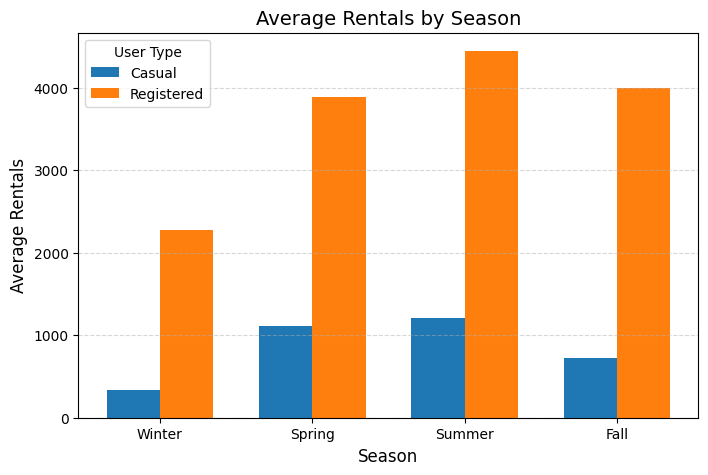

In [ ]:
# Step 1: Calculate averages by season
casual_avg = df.groupby("season")["casual"].mean()
registered_avg = df.groupby("season")["registered"].mean()

# Step 2: Create x positions
x = np.arange(len(casual_avg))
width = 0.35

plt.figure(figsize=(8, 5))

# Step 3: Plot bars side by side
plt.bar(x - width/2, casual_avg.values, width, label="Casual")
plt.bar(x + width/2, registered_avg.values, width, label="Registered")

# Step 4: Formatting
plt.title("Average Rentals by Season", fontsize=14)
plt.xlabel("Season", fontsize=12)
plt.ylabel("Average Rentals", fontsize=12)

plt.xticks(x, ["Winter", "Spring", "Summer", "Fall"])  # corrected
plt.legend(title="User Type")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

## 5.5.3 Stacked Bar Charts

A stacked bar chart displays multiple numerical values
stacked on top of each other within each category.

This allows us to:

- Compare total values across categories
- See how each component contributes to the total

In this example, we will visualize:

Total rentals by season,
stacked as **casual + registered users**.

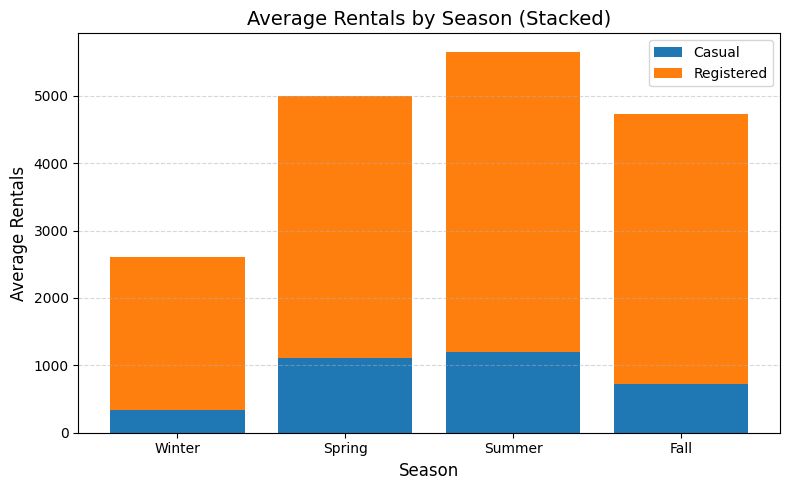

In [ ]:
# Step 1: Aggregate total rentals by season
season_totals = df.groupby("season")[["casual", "registered"]].mean()

casual_avg = season_totals["casual"].values
registered_avg = season_totals["registered"].values

# Step 2: Create x positions
x = np.arange(len(season_totals))

plt.figure(figsize=(8, 5))

# Step 3: Draw bottom layer
plt.bar(x, casual_avg, label="Casual")

# Step 4: Stack second layer on top
plt.bar(x, registered_avg, bottom=casual_avg, label="Registered")

# Step 5: Formatting
plt.title("Average Rentals by Season (Stacked)", fontsize=14)
plt.xlabel("Season", fontsize=12)
plt.ylabel("Average Rentals", fontsize=12)

plt.xticks(x, ["Winter", "Spring", "Summer", "Fall"])  # fixed order

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

- `bottom=casual_avg`  
  Places the second bar on top of the first.

- The first `plt.bar()` call forms the base.

- The second `plt.bar()` call stacks on top by using
  the values of the lower bar as the starting point.

Stacked bar charts are useful for showing
**part-to-whole relationships within categories**.

It has already been explained, but you can use the `help` function to look up the function parameters and other details.

In [ ]:
help(plt.legend)

Help on function legend in module matplotlib.pyplot:

legend(*args, **kwargs) -> 'Legend'
    Place a legend on the Axes.

    Call signatures::

        legend()
        legend(handles, labels)
        legend(handles=handles)
        legend(labels)

    The call signatures correspond to the following different ways to use
    this method:

    **1. Automatic detection of elements to be shown in the legend**

    The elements to be added to the legend are automatically determined,
    when you do not pass in any extra arguments.

    In this case, the labels are taken from the artist. You can specify
    them either at artist creation or by calling the
    :meth:`~.Artist.set_label` method on the artist::

        ax.plot([1, 2, 3], label='Inline label')
        ax.legend()

    or::

        line, = ax.plot([1, 2, 3])
        line.set_label('Label via method')
        ax.legend()

    .. note::
        Specific artists can be excluded from the automatic legend element
        selectio

### <Practice Question 5.5.3.1>

Create a stacked bar chart showing the **average casual and registered rentals**
by **working day (0 = No, 1 = Yes)**.

Steps:

1. Group the dataset by `workingday`.
2. Compute the average of `casual` and `registered`.
3. Create a stacked bar chart using `plt.bar()` and the `bottom` argument.
4. Add readable category labels.

After plotting, answer:

- Which user type contributes more on working days?
- Is the composition different on non-working days?

In [ ]:
# Solution

# Step 1: Aggregate data
workingday_avg = # WRITE ME

casual_avg = workingday_avg["casual"].values
registered_avg = workingday_avg["registered"].values

# Step 2: X positions
x = np.arange(len(workingday_avg))

plt.figure(figsize=(8, 5))

# Bottom layer
# WRITE ME

# Stacked layer
# WRITE ME

plt.tight_layout()
plt.show()

# 5.6. Subplots and Multi-Panel Figures

In real analysis, a single graph is often not enough.

We frequently want to compare multiple visualizations side by side.

Subplots allow us to:

- Compare different variables
- Examine multiple relationships
- Present structured insights in one figure
- Tell a clearer story

We will use Matplotlib’s `subplot` functionality to create multi-panel figures.

## 5.6.1 Comparing Distributions

Suppose we want to compare:

- Distribution of total rentals
- Distribution of temperature

Instead of showing two separate figures,
we can place them side-by-side for easier comparison.

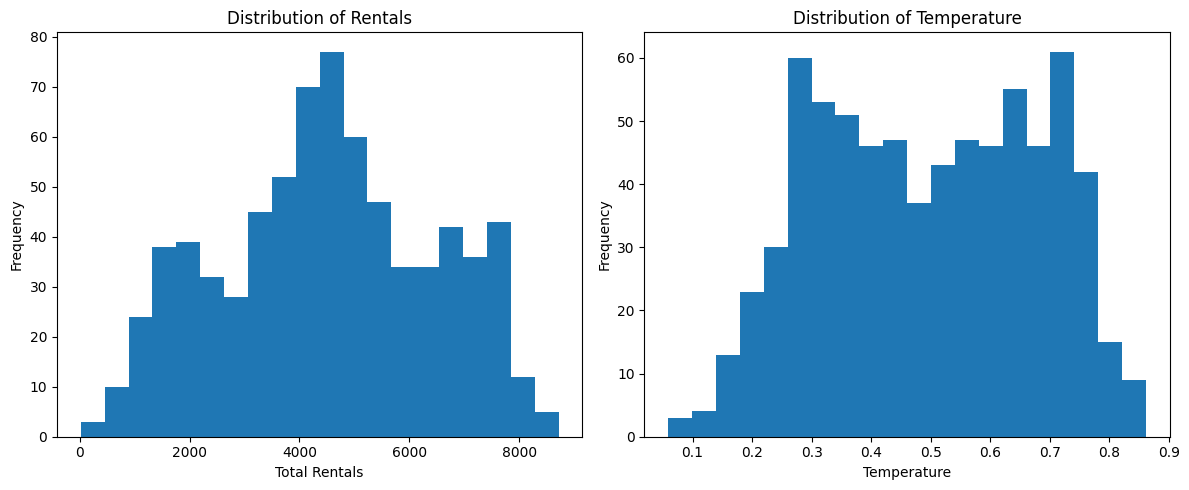

In [ ]:
plt.figure(figsize=(12, 5))

# First subplot
plt.subplot(1, 2, 1)
plt.hist(df["cnt"], bins=20)
plt.title("Distribution of Rentals")
plt.xlabel("Total Rentals")
plt.ylabel("Frequency")

# Second subplot
plt.subplot(1, 2, 2)
plt.hist(df["temp"], bins=20)
plt.title("Distribution of Temperature")
plt.xlabel("Temperature")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### Understanding `plt.subplot(rows, columns, index)`

- `1, 2, 1` means:
  - 1 row
  - 2 columns
  - First position

- `1, 2, 2` means:
  - Same layout
  - Second position

`plt.tight_layout()` prevents overlapping labels.

Subplots allow structured comparison within one figure.

## 5.6.2 Comparing Multiple Relationships

We may want to examine how rentals relate to:

- Temperature
- Humidity
- Wind speed

Instead of three separate plots,
we can create a multi-panel layout.

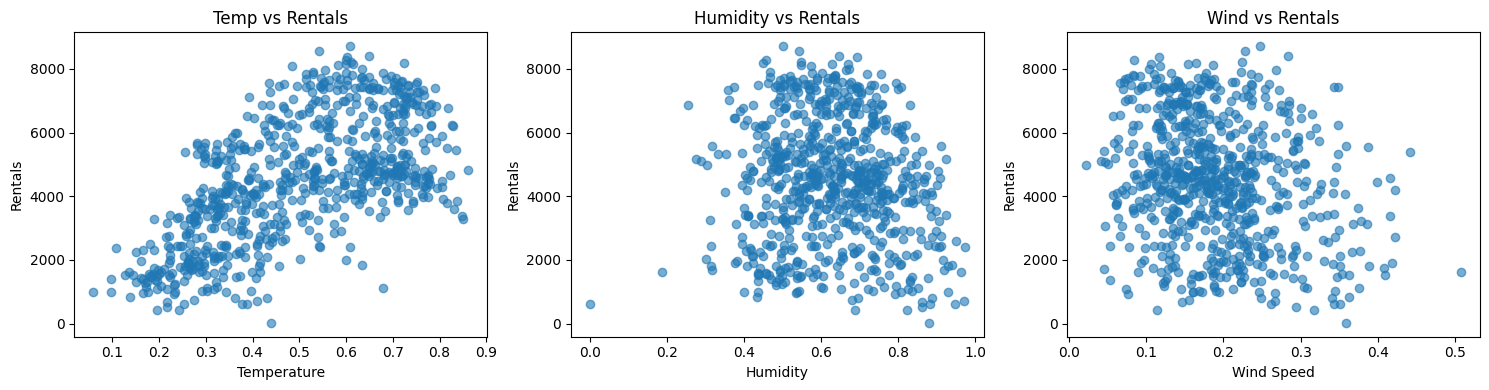

In [ ]:
plt.figure(figsize=(15, 4))

# Temperature vs Rentals
plt.subplot(1, 3, 1)
plt.scatter(df["temp"], df["cnt"], alpha=0.6)
plt.title("Temp vs Rentals")
plt.xlabel("Temperature")
plt.ylabel("Rentals")

# Humidity vs Rentals
plt.subplot(1, 3, 2)
plt.scatter(df["hum"], df["cnt"], alpha=0.6)
plt.title("Humidity vs Rentals")
plt.xlabel("Humidity")
plt.ylabel("Rentals")

# Wind Speed vs Rentals
plt.subplot(1, 3, 3)
plt.scatter(df["windspeed"], df["cnt"], alpha=0.6)
plt.title("Wind vs Rentals")
plt.xlabel("Wind Speed")
plt.ylabel("Rentals")

plt.tight_layout()
plt.show()

This multi-panel layout allows us to visually compare:

- Strength of association
- Direction of relationship
- Variability

For example:
- Temperature may show a stronger positive relationship.
- Wind speed may show weaker association.
- Humidity may show nonlinear patterns.

Subplots make comparison much easier.

## 5.6.3 When Should You Use Subplots?

Use subplots when:

- Comparing multiple variables
- Showing multiple perspectives of the same outcome
- Presenting structured results in reports
- Building dashboards

Avoid subplots when:
- Plots become too small to interpret
- Too many panels create clutter

Clarity should always come first.

# 5.7 Introducing Seaborn: Simplifying Multi-Variable Visualizations

So far, we have created all visualizations using Matplotlib. While Matplotlib provides full control, some plots require significant manual adjustment. For example, in grouped bar charts we had to:

- Manually compute x positions
- Adjust bar width
- Shift bars left and right

Seaborn is built on top of Matplotlib and simplifies many of these tasks. It is especially powerful for:

- Grouped comparisons
- Conditional relationships
- Statistical summaries
- Interaction effects

The key feature we will introduce is:

→ The `hue` parameter

`hue` allows us to add a second categorical variable
that automatically separates groups using color.

## 5.7.2 Grouped bar chart with hue

Before creating grouped visualizations, it is good practice to convert
numeric category codes into readable labels.

In [ ]:
# Improve categorical readability
df["Season"] = df["season"].map({
    1: "Winter",
    2: "Spring",
    3: "Summer",
    4: "Autum"
})

df["Working Day"] = df["workingday"].map({
    0: "No",
    1: "Yes"
})

In Seaborn, instead of manually controlling bar positions, we specify:

- `x` → primary categorical variable  
- `y` → numerical variable to summarize  
- `hue` → secondary categorical variable  

Seaborn automatically:

- Groups the data
- Computes summary statistics (mean by default)
- Positions bars side by side
- Applies distinct colors
- Generates a legend

Let us revisit a similar business question:

> Do working days and non-working days show different rental patterns,  
> and does this difference vary by season?

To explore this interaction, we will use:

- `Working Day` as the x-axis category  
- `cnt` (total rentals) as the numerical outcome  
- `Season` as the `hue` variable  

Notice how much cleaner the code becomes compared to the Matplotlib version.

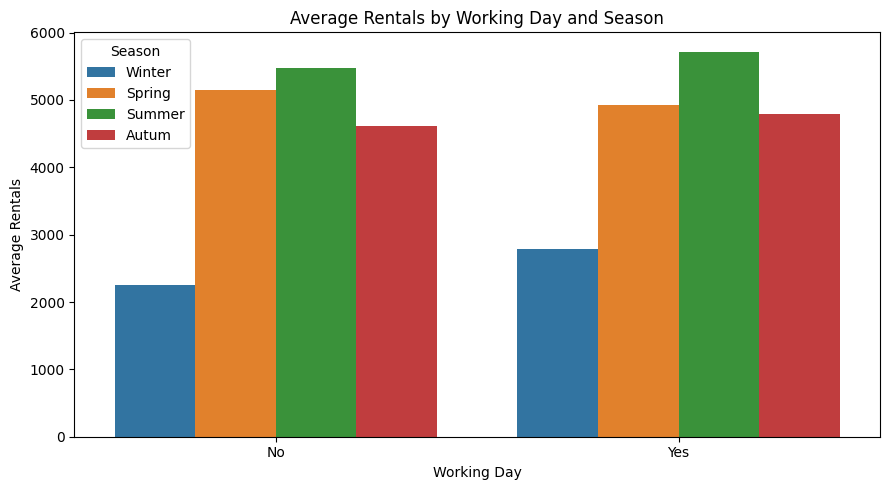

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="Working Day",
    y="cnt",
    hue="Season",
    estimator="mean",
    errorbar=None
)

plt.title("Average Rentals by Working Day and Season")
plt.xlabel("Working Day")
plt.ylabel("Average Rentals")

plt.tight_layout()
plt.show()

## 5.7.3 Scatter Plot with Hue

Earlier, we examined: Temperature vs Rentals.

Now we ask: Does this relationship differ across seasons?

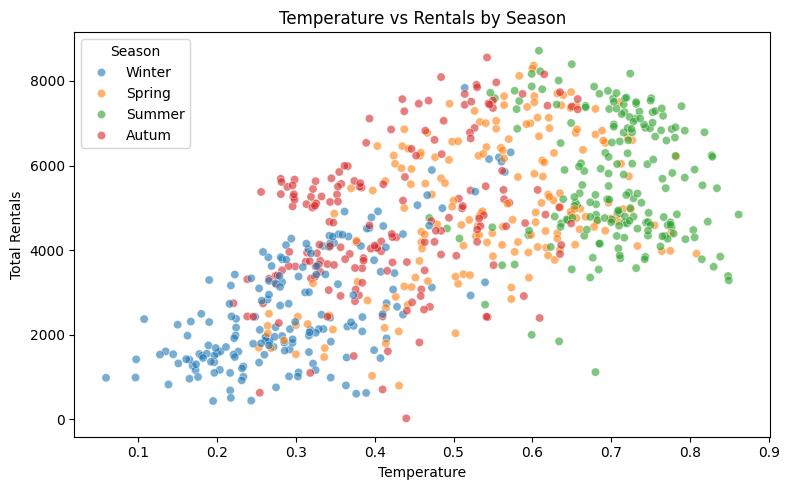

In [ ]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="temp",
    y="cnt",
    hue="Season",
    alpha=0.6
)

plt.title("Temperature vs Rentals by Season")
plt.xlabel("Temperature")
plt.ylabel("Total Rentals")

plt.tight_layout()
plt.show()

### Interpreting the Plot

This scatter plot again shows the relationship between temperature and total daily rentals, but now the points are colored by season. This allows us to see how the temperature–demand relationship varies throughout the year. First, the overall pattern still shows a positive relationship between temperature and rentals. As temperature increases, the number of rentals generally rises. Colder days tend to have fewer rentals, while warmer days tend to attract more riders.

Looking at the seasonal patterns:

* Winter observations appear mostly at the lowest temperatures and generally correspond to the lowest rental levels.

* Spring covers moderate temperatures, where rentals begin to increase as the weather becomes more favorable.

* Summer contains the highest temperature values and many of the highest rental counts, indicating higher demand during warm weather.

* Autumn overlaps somewhat with both summer and spring temperatures but still shows relatively high rental activity, though slightly lower on average than peak summer days.

The seasonal coloring highlights that while temperature is an important driver of demand, it does not fully explain rental patterns. Seasonal factors such as daylight hours, tourism, commuting behavior, and overall weather conditions likely also influence usage.

Overall, the plot suggests that both temperature and season play important roles in shaping bike rental demand.

## 5.7.4 Boxplot with Hue

We now examine rental variability under different weather conditions,
while also differentiating by season.

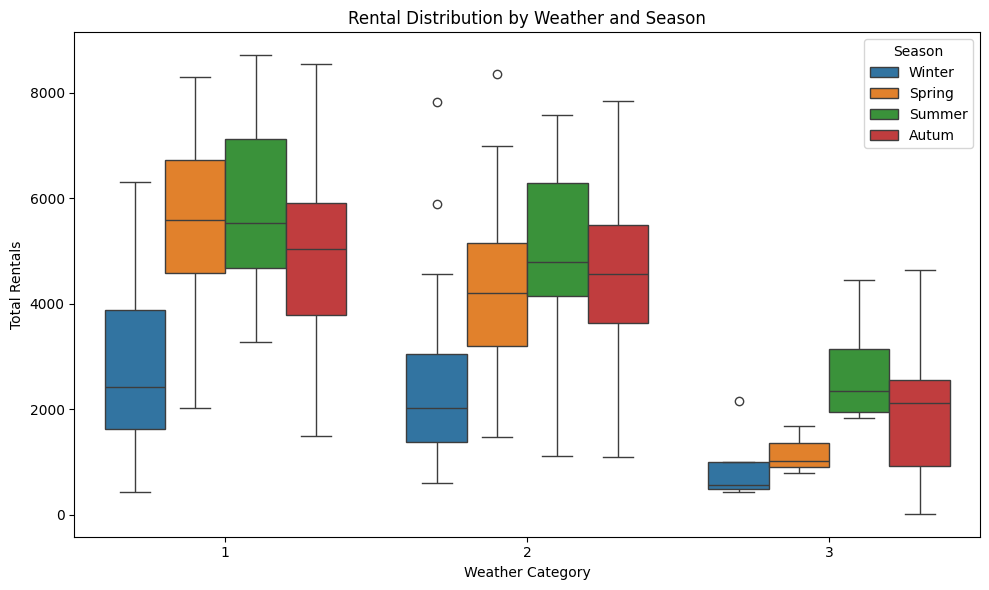

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="weathersit",
    y="cnt",
    hue="Season"
)

plt.title("Rental Distribution by Weather and Season")
plt.xlabel("Weather Category")
plt.ylabel("Total Rentals")

plt.tight_layout()
plt.show()

### Interpreting the Plot

Several patterns emerge from this visualization.

First, weather conditions influence rental demand. Across all seasons, best weather (category 1) tends to have the highest rental levels, while second best conditions (category 2) show somewhat lower demand. Category 3 corresponds to the lowest rental counts, indicating that poor weather discourages bike usage.

Second, seasonal differences remain visible within each weather category.
Even under the same weather conditions, summer and autumn generally show higher rental levels, while winter consistently has the lowest demand. This suggests that other seasonal factors also influence rentals beyond immediate weather conditions.

Third, the boxplots reveal differences in variability.
Clear-weather days show a wider spread in rental values, especially during warmer seasons. This indicates that favorable conditions can lead to both typical commuting demand and very high peak usage days.

Overall, the plot suggests that both weather and season jointly affect rental demand. Clear weather and warmer seasons tend to produce the highest rental activity, while poor weather conditions significantly reduce usage across all seasons.

Using Seaborn’s `hue` parameter, we can:

- Compare multiple groups simultaneously
- Detect interaction effects
- Examine conditional relationships
- Move beyond simple averages

Seaborn simplifies complex grouped analysis and allows us
to focus more on interpretation than mechanics.

# 5.8. Correlation Analysis and Heatmaps

So far, we have explored relationships visually, one pair at a time.

However, our dataset contains many numerical variables:

- Temperature (`temp`)
- Humidity (`hum`)
- Wind speed (`windspeed`)
- Casual rentals (`casual`)
- Registered rentals (`registered`)
- Total rentals (`cnt`)

Instead of analyzing each pair separately,
we can compute a **correlation matrix**.

A correlation matrix shows how all numerical variables
relate to each other simultaneously.

## 5.8.1 Understanding Correlation

Correlation measures the strength and direction of a linear relationship between two variables.

- Values range from **-1 to 1**
- Positive values → variables increase together
- Negative values → one increases while the other decreases
- Values near 0 → weak linear association

Formally, the correlation coefficient can be calcultaed by dividing the covariance by the standard deviation of each variable (see Appendix for details).


**Important**:

Correlation does NOT imply causation.
It only measures statistical association.

(Although it is not covered in detail in this course, if you want to understand the causal relationship, we will use an approach called **design of experiment**. For example, if you want to know whether a certain marketing measure was effective or not after viewing an advertisement, you divide the group into two groups: a treatment group that is shown the advertisement and a control group that is not shown any advertisement, and then calculate the ratio of the two groups).

## 5.8.2 Computing the Correlation Matrix
Instead of automatically selecting every numeric column,
we explicitly choose relevant features to avoid unnecessary noise.

In [ ]:
# Select relevant numerical variables
numeric_df = df[[
    "temp",
    "hum",
    "windspeed",
    "casual",
    "registered",
    "cnt"
]]

# Compute correlation matrix
corr_matrix = numeric_df.corr()

corr_matrix

,temp,hum,windspeed,casual,registered,cnt
temp,1.000000,0.126963,-0.157944,0.543285,0.540012,0.627494
hum,0.126963,1.000000,-0.248489,-0.077008,-0.091089,-0.100659
windspeed,-0.157944,-0.248489,1.000000,-0.167613,-0.217449,-0.234545
casual,0.543285,-0.077008,-0.167613,1.000000,0.395282,0.672804
registered,0.540012,-0.091089,-0.217449,0.395282,1.000000,0.945517
cnt,0.627494,-0.100659,-0.234545,0.672804,0.945517,1.000000


Each cell represents the correlation between two variables.

For example:
- Temperature vs total rentals
- Humidity vs rentals
- Casual vs registered users

However, reading a table of numbers is difficult.

To interpret correlations quickly, we use a heatmap.

## 5.8.3 Visualizing Correlation with a Heatmap

**Heat maps** are suitable for visualizing correlation matrices. A heat map is a method to visualize the coefficient values of each feature pair using a color gradient. This can be easily created using the seaborn library.

Let's visualize the Pandas correlation matrix created above by specifying it as an argument.

Below, we further improve clarity by:
- Centering the color scale at 0
- Using consistent formatting
- Adding square cells

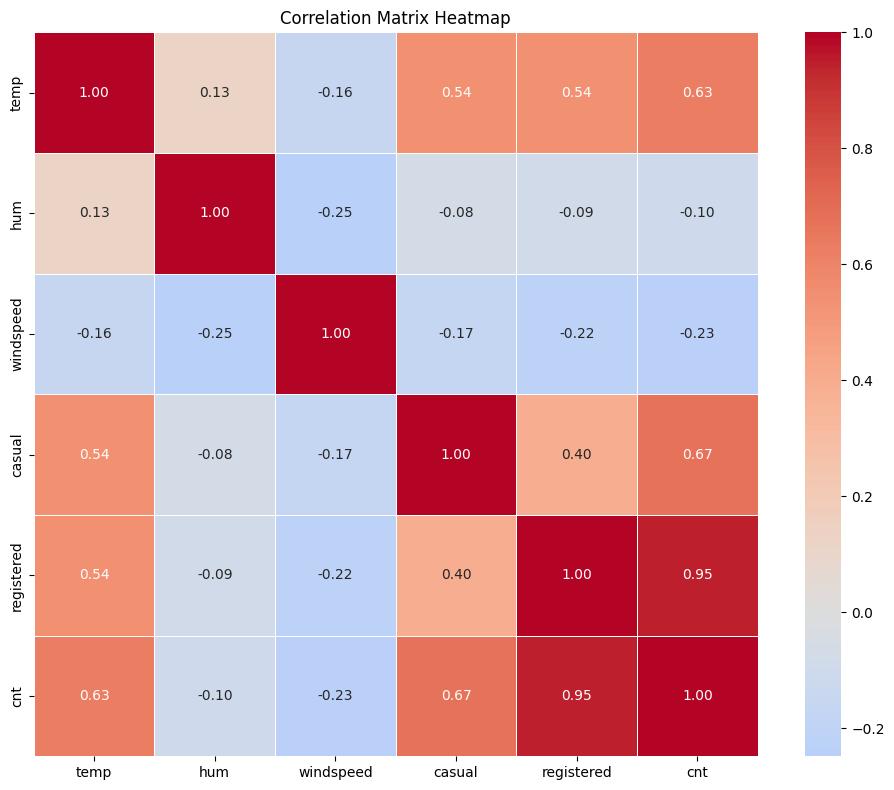

In [ ]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    center=0,
    square=True,
    linewidths=0.5
)

plt.title("Correlation Matrix Heatmap")
plt.tight_layout()
plt.show()

The heatmap allows us to quickly identify:

- Strong positive correlations (deep red)
- Strong negative correlations (deep blue)
- Weak relationships (near white)

Observations may include:

- Total rentals (`cnt`) strongly correlated with `registered`
- Positive relationship between temperature and rentals
- Weaker relationship between humidity and rentals

## 5.8.4 Important Limitationss
Correlation analysis has limitations:

- It captures only linear relationships.
- It does not imply causation.
- It does not control for other variables.
- It can be influenced by outliers.

Correlation is a starting point —
not a final conclusion.

# 5.9. Regression and Trend Analysis

So far, we have:

- Visualized trends
- Compared groups
- Examined correlations

Correlation showed us whether variables move together.

Now we go one step further.

Instead of only visualizing raw scatter points,
we estimate a **regression line** that summarizes
the average relationship between variables.

Regression helps us:

- Estimate the direction of association
- Approximate the strength of a linear relationship
- Visually summarize noisy data

## 5.9.1 Adding a Regression Line

We revisit our earlier question:

Does temperature influence rental demand?

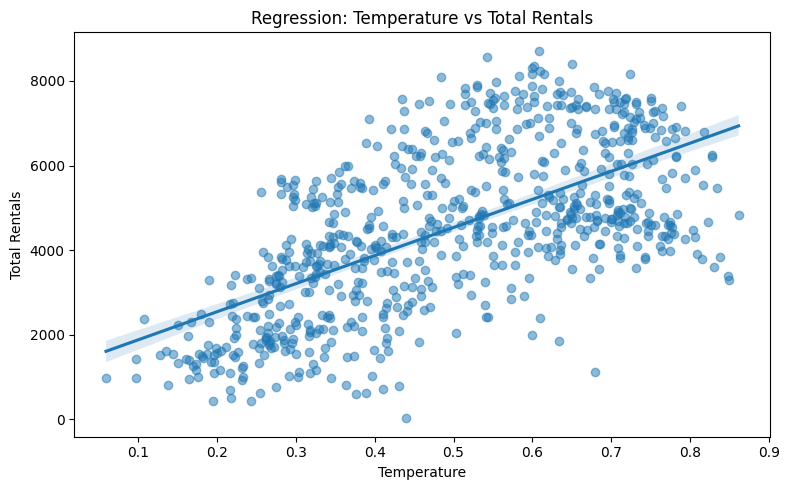

In [ ]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="temp",
    y="cnt",
    scatter_kws={"alpha": 0.5}
)

plt.title("Regression: Temperature vs Total Rentals")
plt.xlabel("Temperature")
plt.ylabel("Total Rentals")

plt.tight_layout()
plt.show()

- `sns.regplot()`  
  Creates a scatter plot and automatically fits a linear regression line.

- `data=df`  
  Specifies the dataset.

- `x="temp"`  
  Independent variable (predictor).

- `y="cnt"`  
  Dependent variable (response).

- `scatter_kws={"alpha": 0.5}`  
  Adjusts properties of the scatter points.
  Here, `alpha` controls transparency.
  Lower values reduce overplotting when points overlap.

- `plt.tight_layout()`  
  Automatically adjusts spacing to prevent clipping of labels.

The regression line summarizes the overall linear trend.

If the line slopes upward:
- Higher temperatures are associated with higher rental demand.

If the slope slopes downward:
- Higher temperatures are associated with lower demand.

The shaded region represents a confidence interval,
indicating uncertainty around the estimated trend.

## 5.9.2 Regression by Season (Interaction Insight)

Earlier, we explored scatter plots with color differentiation.

Now we estimate separate regression lines by season.

While `regplot()` draws a single regression line,
`sns.lmplot()` allows us to estimate separate regression lines
for different groups using the `hue` parameter.

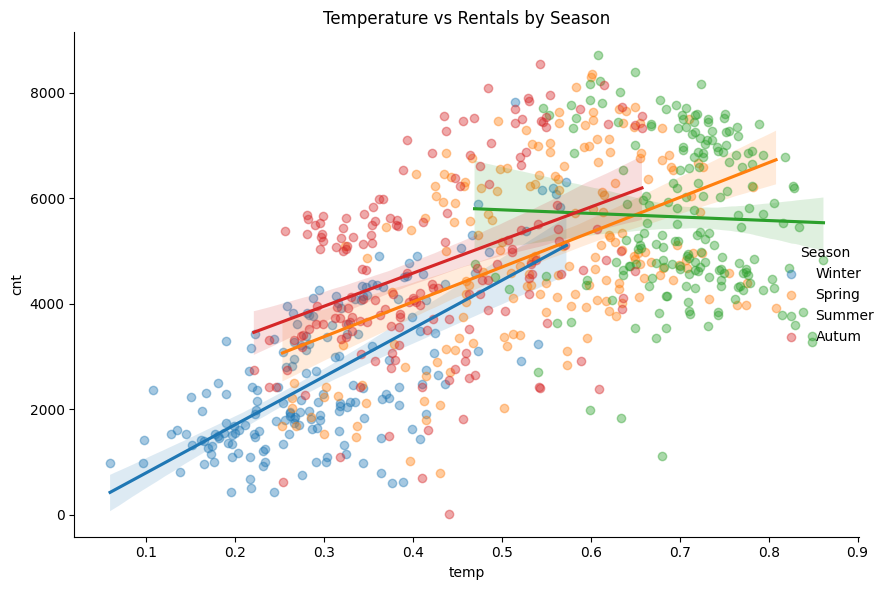

In [ ]:
sns.lmplot(
    data=df,
    x="temp",
    y="cnt",
    hue="Season",
    height=6,
    aspect=1.3,
    scatter_kws={"alpha": 0.4}
)

plt.title("Temperature vs Rentals by Season")
plt.tight_layout()
plt.show()

- `sns.lmplot()`  
  Creates scatter plots with regression lines.
  Unlike `regplot()`, it supports grouping via `hue`.

- `hue="Season"`  
  Fits a separate regression line for each season.

- `height=6`  
  Controls the height (in inches) of the plot.

- `aspect=1.3`  
  Controls the width-to-height ratio.
  Larger values make the plot wider.

- `scatter_kws={"alpha": 0.4}`  
  Makes the scatter points more transparent to reduce clutter.

This visualization allows us to observe:

- Whether slopes differ across seasons
- Whether some seasons are more temperature-sensitive
- Whether baseline rental levels differ
- Whether relationships appear stronger or weaker by season

## 5.9.3 Connecting Correlation and Regression

Correlation measures association strength.

Regression estimates the relationship explicitly
by fitting a best-fit line.

If correlation is strong,
the regression line will typically show a clear slope.

If correlation is weak,
the regression line will appear flatter.

## 5.9.4 Important Cautions

Regression plots:

- Show association, not causation
- Assume a linear relationship
- May hide nonlinear effects
- Can be influenced by outliers

Visualization helps generate hypotheses,
but formal statistical modeling is required
for causal claims.

# 5.10. Key Insights for the Bike Sharing Manager

Throughout this analysis, we explored rental demand using visualization.

Let us summarize the most important findings.

## 5.10.1 Summary of Findings

From our visual analysis:

- Rental demand fluctuates over time.
- Temperature appears positively associated with rentals.
- Working days and weekends may differ in average demand.
- Seasonal effects are substantial.
- Weather conditions influence variability.
- Registered users behave more consistently than casual users.

These insights can guide:

- Staffing decisions
- Bike redistribution strategies
- Seasonal planning
- Weather-based forecasting adjustments

## 5.10.2 Final Reflection

Visualization is a powerful first step in exploratory data analysis.

By:

- Structuring questions clearly
- Building clean and interpretable plots
- Comparing groups thoughtfully
- Evaluating relationships carefully

We transform raw data into actionable insight.

This concludes our Bike Sharing Demand visualization analysis.

# Appendix

## A-1 Plotting Function Graphs

Using matplotlib, you can easily plot any function. <br>
First, define the function you wish to plot using the `def` statement, and then simply pass it as an argument to `plt.plot()`. <br>
In the code below, we are plotting the function $f(x) = x^2 + 2x +1$ as an example. However, you can easily plot various functions by modifying the contents within the `def` statement.

Experiment with different expression in the `def` statement to get used to it.

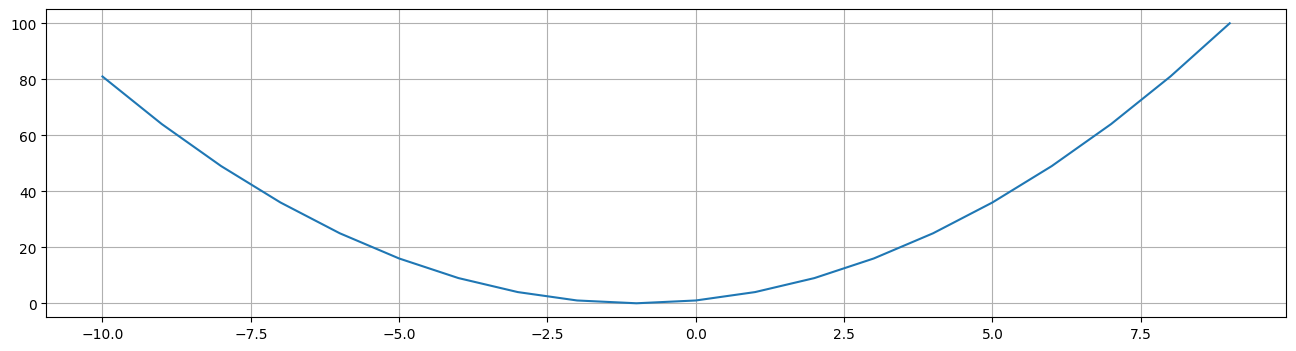

In [ ]:
# Function definition
def my_function(x):
    return x ** 2 + 2 * x + 1

x = np.arange(-10, 10)
plt.figure(figsize = (16, 4))
plt.plot(x, my_function(x))
plt.grid(True)

#### <Practice Question 1>

Plot the graph of $y = 5x + 3$ for $x$ values ranging from $-10$ to $10$.

In [ ]:
x = np.linspace(-10, 10, 100)
y = # WRITE ME

# WRITE ME

#### <Practice Question 2>

By using `plt.plot()` multiple times, you can plot multiple graphs in the same plot.

Plot the graphs of $y = sin(x)$ and $y = cos(x)$ on the same plot for $x$ values ranging from $-10$ to $10$.

In [ ]:
x = np.linspace(-10, 10, 100)

# WRITE ME

## A-2: KDE Plots

In seaborn, we can plot the **kernel density estimate (KDE)** by setting `kde=True` in `sns.histplot()`, which shows where the peaks of the distribution are concentrated.

In [ ]:
plt.figure(figsize = (12, 4))

sns.histplot(data=iris, x='sepal_length', hue='species', bins=25, binrange=(4.5, 7.5), kde=True)
plt.xlabel('Sepal Length')
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)

Seaborn library also has a separate plotting function for visualizing KDE, `sns.kdeplot()`.

## A-3: Variance, Standard Deviation, Covariance, Correlation Coefficient

First, the **average** (or mean) for data $x$ is calculated as follows:

$$
\bar{x}=\frac{1}{n}\sum_{i=1}^nx_i
$$

Next, the **variance**, often denoted $\sigma^2$, is calculated as:

$$
\sigma^2=\frac{1}{n-1}\sum_{i=1}^n(x_i-\bar{x})^2
$$

This tells us if the data is scattered or clumped (around the mean).

*The formula above os for "unbiased variance" to be more precise.

The **standard deviation** is the square root of the variance and is commonly denoted by $\sigma$:

$$
\sigma=\sqrt{\frac{1}{n-1}\sum_{i=1}^n(x_i-\bar{x})^2}
$$

Variance does not tell us how much the actual scattering of the data is. This is because, as you can see from the definition formula for variance presented above, it is squared in the formula. If we use the standard deviation, the dimension of the unit matches the actual data.

Next, we will consider quantifying the relationship between two variables. **Covaricance** is a measure for looking at the relationship between two variables which is defined as below. The covariance is $S_{xy}$ and shows the relationship between the two variables, $x, y$.

$$
S_{xy}=\frac{1}{n}\sum_{i=1}^n(x_i-\bar{x})(y_i-\bar{y})
$$

Covariance is the average of the product of the deviations of two sets of variables. It is used when considering the variance of two or more sets of variables. Numpy has a function to calculate the matrix of covariance (covariance matrix), which can be obtained using the `np.cov()` function.

According to its definition, covariance is dependent on the scale and units of each variable. On the other hand, the **correlation coefficient** quantifies the relationship between two variables without being affected by their scales. The formula that divides the covariance by the standard deviation of each variable (here $ x $ and $ y $) is the correlation coefficient. Its definition is as follows. The correlation coefficient is commonly denoted by $r_{xy}$.

$$
r_{xy}=\frac{\sum_{i=1}^n(x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum_{i=1}^n(x_i-\bar{x})^2}\sqrt{\sum_{i=1}^n(y_i-\bar{y})^2}}
$$

## A-3: Visualizing Financial Data (Advanced)

In this section, we will discuss the visualization of financial data.

In [ ]:
# Setting date data. Generate data every minute with freq=`T`.
idx = pd.date_range('2015/01/01', '2015/12/31 23:59', freq='T')

# Generate random values, producing either 1 or -1.
dn = np.random.randint(2, size = len(idx)) * 2 - 1

# Create a random walk (data where values increase or decrease randomly)
# np.cumprod calculates the cumulative product (the product of the first element, the second element, the third element, etc.).
rnd_walk = np.cumprod(np.exp(dn * 0.0002)) * 100

# Resample the data on business days using resample(`B`).
# Use the ohlc method to obtain four data points: "open," "high," "low," and "close."
df = pd.Series(rnd_walk, index=idx).resample('B').ohlc()

When plotted as is, the result appears as shown below. Here, we are using Pandas' visualization feature. Since the values are generated randomly, the graph will differ from the one presented in print.

In [ ]:
df.plot(figsize = (15,6), legend = 'best', grid = True)

Let's display this graph as a candlestick chart. To do this, you will need the Plotly library. In a Jupyter Notebook cell, enter `!pip install plotly` and run it to install the library.

For more information on displaying candlestick charts, please refer to the reference USL "B-23."

In [ ]:
!pip install plotly

Using the candlestick chart creation features of the Plotly library, you can beautifully display the graph as shown below. You can also zoom in on the graph interactively. Hovering over it displays the numbers, making it very convenient.

In [ ]:
# Import the plotly model
from plotly.offline import init_notebook_mode, iplot
from plotly import figure_factory as FF

# Set up for Jupyter Notebook
init_notebook_mode(connected=False)

# Configuration for Google Colaboratory
def configure_plotly_browser_state():
  import IPython
  display(IPython.core.display.HTML('''
        <script src="/static/components/requirejs/require.js"></script>
        <script>
          requirejs.config({
            paths: {
              base: '/static/base',
              plotly: 'https://cdn.plot.ly/plotly-latest.min.js?noext',
            },
          });
        </script>
        '''))
configure_plotly_browser_state()

# Set up the candlestick chart
fig = FF.create_candlestick(df.open, df.high, df.low, df.close, dates = df.index)
iplot(fig)

## A-4: Automating EDA (Advanced)

Conducting **Exploratory Data Analysis (EDA)** requires numerous visualization tasks while repeatedly performing analysis. However, there are many libraries proposed to enhance work efficiency by automating the routine aspects of such tasks. Below are some examples of such libraries. Since we won't go into details here, please refer to the official documentation to explore their usage according to your interest.   

The libraries introduced here are relatively simple and focus on basic functionality, but there are also many libraries with broader capabilities available. What's important is not getting too comfortable with specific libraries but staying aware of new, convenient tools that keep emerging. It is crucial to consistently keep up with more efficient and effective methods.

**Pandas-Profiling** is a simple automation tool that you can use for EDA. Since this library is not among the pre-installed list in Google Colab, you will first need to execute `!pip install`.


In [ ]:
# Install Pandas-Profiling
!pip install https://github.com/ydataai/pandas-profiling/archive/master.zip

# Downgrade Pandas-Profiling dependencies
!pip install markupsafe==2.0.1

When you run the code above, you may see several warning messages, including one that says "Please restart the runtime." If this message appears, select "Runtime" → "Restart runtime" from the menu bar in Google Colab. Once the runtime has restarted, continue executing the following code.

In [ ]:
# Here, we will use a dataset of California real estate as an example.
import pandas as pd
from sklearn.datasets import fetch_california_housing
CH = fetch_california_housing()
df = pd.DataFrame(CH.data, columns= CH.feature_names)
df['MedHouseVal'] = CH.target
df.head(3)

The successful completion of the execution will result in the output of an HTML format visualization report. Since it is interactive, you can analyze the relationships between various features by using your mouse to navigate through the report.

While this visualization report alone may not complete the EDA, it allows you to quickly address certain standardized aspects, facilitating a smoother transition into more in-depth analysis.

## Side Notes

### Side Note 1: Visualization Using Pandas

Pandas has built-in visualization capabilities that allow you to create graphs using the `plot()` method. For example, appending "`.plot(kind='bar')`" after your DataFrame will generate a vertical bar graph. If you use "`kind='barh'`," it will create a horizontal bar graph, and "`kind='pie'`" will produce a pie chart. Feel free to use these when needed. Try generating different types of visualizations using various datasets to see what you can create.

### Side Note 2: Various Data Visualization

Data visualization can be accomplished not only with Python but also with various programming languages and libraries, providing references for graphing in Python. For example, JavaScript has a popular library called "D3.js," which can create a variety of visual representations. Although this library is used with JavaScript rather than Python, it offers valuable insights into how to visualize data from multiple perspectives.

### Side Note 3: Key Points for Presenting Data Analysis

The reporting of data analysis results can occur in various contexts, such as reporting to upper management in your current company or making proposals to clients. While there are many resources available for document creation methods, the following points are universally important.

- Clearly define the purpose of the data analysis and what you want to show.

- Consider who will receive the analysis results.

- Don’t start creating materials immediately; don’t open PowerPoint right away—think first.

- What specific actions do you want to encourage by showing these results?

- How much profit could be gained, or how much could costs be reduced by implementing these actions?

- Clearly outline what you will discuss and provide a table of contents (agenda) to show the overall picture.

- Generally, present the conclusion first.

- Avoid overloading with information; eliminate unnecessary content.

- State your main point in one sentence, supported by visualized data (tables).

- Think about the narrative or story you want to convey.

Additionally, there are points to consider when explaining to others, such as avoiding the use of 3D graphs, though this can depend on the context. It's essential to think about who will be viewing the results.

As mentioned earlier, visualizing data can also be done using Excel or other tools (like Tableau). This book adopts Python, using Matplotlib for displaying graphs, but there's no need to force the use of Matplotlib in a business setting. If the dataset is not too large, Excel is very effective for quickly visualizing data. Make your tool selection based on the specific case at hand.

### Bonus Question：Monte Carlo Method

Using random number generation, create a program to estimate the value of π (pi). This approach is known as the **Monte Carlo method**.

（1）Generate two sets of random numbers that follow a uniform distribution over the interval `[0,1)`, with each set containing 10,000 uniformly distributed random numbers.
A uniformly distributed random number is one that has an equal probability of occuring within a specified range. Use `np.random.uniform` for this purpose. For example, `np.random.uniform(0.0, 1.0, 10)` generates 10 random numbers within the range of 0 to 1.

（2）Consider a circle with its center at $(0,0)$ and a radius of 1 on the $x-y$ plane, and a square with a side length of 1. The area of the circle will be $\pi$, and the area of the square will be 1. Out of the 10,000 pairs of random numbers generated earlier, how many points will fall inside the circle?

To determine if a point lies inside the circle, calculate the Euclidean norm ($\sqrt{x^2 + y^2}$). If this length is less than 1, the point is inside the circle. You can use `math.hypot(x,y)` in Python to calculate the length. If you're up for a challenge, try plotting the points inside and outside the circle.


（3）The area ratio of a quarter of a circle with a radius of 1 to the area of a square with a side length of 1 is $ \pi /4 : 1$. Using this ratio and the results from step 2, calculate the value of $π$.